# Feature Engineering: Developer Journey, Persona, and Validation Pipeline

This notebook updates the original feature-engineering prototype to match the midpoint presentation design.

Main changes:
- Build a reusable `activity_enriched_v1` layer before feature engineering.
- Create an activity ontology with **four tags**: `journey_signal`, `effort_level`, `persona_hint`, and `modality`.
- Build **cumulative 30, 90, and 180 day feature tables** for journey state assignment.
- Add rule-based journey state, persona assignment, confidence, and transition analysis.
- Add validation gates after every major table so issues are caught early.

The guiding principle is simple: every derived table should have a validation block immediately after it.


In [33]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DB_PATH = "developer_project.duckdb"
con = duckdb.connect(DB_PATH)

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

# Change these only if your cleaned notebook uses different final table names.
ACTIVITY_TABLE = "activity_final"
CONTACT_TABLE = "contact_final"


In [34]:
con.execute("""
SHOW TABLES
""").fetchdf()

,name
0,activity_base
1,activity_clean
2,activity_enriched_v1
3,activity_final
4,activity_ontology_v1
5,activity_raw
6,activity_score_mapping_clean
7,activity_score_mapping_raw
8,activity_work
9,contact_clean


## 1. Source table checks

Before building features, confirm that the expected source tables exist and inspect their basic scale.


In [35]:
tables = con.execute("SHOW TABLES").fetchdf()
display(tables)

required = {ACTIVITY_TABLE, CONTACT_TABLE}
missing = required - set(tables.iloc[:, 0].astype(str))
if missing:
    raise ValueError(f"Missing expected table(s): {missing}. Update ACTIVITY_TABLE / CONTACT_TABLE or run cleaning first.")


,name
0,activity_base
1,activity_clean
2,activity_enriched_v1
3,activity_final
4,activity_ontology_v1
5,activity_raw
6,activity_score_mapping_clean
7,activity_score_mapping_raw
8,activity_work
9,contact_clean


In [36]:
for table in [ACTIVITY_TABLE, CONTACT_TABLE]:
    print(f"{table}")
    display(con.execute(f"SELECT COUNT(*) AS rows FROM {table}").fetchdf())
    display(con.execute(f"DESCRIBE {table}").fetchdf())


activity_final


,rows
0,69347501


,column_name,column_type,null,key,default,extra
0,dev_contact,VARCHAR,YES,None,None,None
1,activity,VARCHAR,YES,None,None,None
2,activity_name,VARCHAR,YES,None,None,None
3,activity_type,VARCHAR,YES,None,None,None
4,activity_role,VARCHAR,YES,None,None,None
5,activity_attendance,VARCHAR,YES,None,None,None
6,activity_score,DOUBLE,YES,None,None,None
7,activity_date,DATE,YES,None,None,None
8,activity_id,VARCHAR,YES,None,None,None
9,filepath,VARCHAR,YES,None,None,None


contact_final


,rows
0,9381490


,column_name,column_type,null,key,default,extra
0,developer_id,VARCHAR,YES,None,None,None
1,program_application_source,VARCHAR,YES,None,None,None
2,country,VARCHAR,YES,None,None,None
3,region,VARCHAR,YES,None,None,None
4,sub_region,VARCHAR,YES,None,None,None
5,zone,VARCHAR,YES,None,None,None
6,territory,VARCHAR,YES,None,None,None
7,organization_english_name,VARCHAR,YES,None,None,None
8,development_areas,VARCHAR,YES,None,None,None
9,other_development_areas,VARCHAR,YES,None,None,None


## 2. Validate source keys, dates, and duplicates

This block follows the midpoint notes: track row counts, missing values, duplicates, and invalid dates before feature engineering.


In [37]:
source_validation = con.execute(f"""
WITH activity_checks AS (
    SELECT
        COUNT(*) AS activity_rows,
        SUM(CASE WHEN dev_contact IS NULL OR TRIM(CAST(dev_contact AS VARCHAR)) = '' THEN 1 ELSE 0 END) AS missing_dev_contact,
        SUM(CASE WHEN activity_date IS NULL THEN 1 ELSE 0 END) AS missing_activity_date,
        SUM(CASE WHEN activity_date > CURRENT_DATE THEN 1 ELSE 0 END) AS future_activity_dates,
        COUNT(*) - COUNT(DISTINCT (COALESCE(CAST(dev_contact AS VARCHAR),'') || '|' ||
                                    COALESCE(CAST(activity_date AS VARCHAR),'') || '|' ||
                                    COALESCE(CAST(activity AS VARCHAR),'') || '|' ||
                                    COALESCE(CAST(activity_name AS VARCHAR),''))) AS possible_duplicate_activity_rows
    FROM {ACTIVITY_TABLE}
),
contact_checks AS (
    SELECT
        COUNT(*) AS contact_rows,
        COUNT(DISTINCT developer_id) AS distinct_developers,
        SUM(CASE WHEN developer_id IS NULL OR TRIM(CAST(developer_id AS VARCHAR)) = '' THEN 1 ELSE 0 END) AS missing_developer_id
    FROM {CONTACT_TABLE}
)
SELECT *
FROM activity_checks
CROSS JOIN contact_checks
""").fetchdf()

display(source_validation)


100% ▕██████████████████████████████████████▏ (00:00:02.13 elapsed)     


,activity_rows,missing_dev_contact,missing_activity_date,future_activity_dates,possible_duplicate_activity_rows,contact_rows,distinct_developers,missing_developer_id
0,69347501,0.0,0.0,0.0,33695697,9381490,9381490,0.0


## 3. Create `activity_enriched_v1`

This table joins activity rows to contact metadata. It is the foundation for all downstream persona and journey features.

Important validation target: the row count should match `activity_final` unless the contact table has duplicate developer IDs.


In [38]:
con.execute(f"""
CREATE OR REPLACE TABLE activity_enriched_v1 AS
WITH contact_one_row AS (
    SELECT *
    FROM (
        SELECT
            c.*,
            ROW_NUMBER() OVER (
                PARTITION BY developer_id
                ORDER BY last_modified_date DESC NULLS LAST, created_date DESC NULLS LAST
            ) AS rn
        FROM {CONTACT_TABLE} c
    )
    WHERE rn = 1
)
SELECT
    a.dev_contact AS developer_id,
    CAST(a.activity_date AS DATE) AS activity_date,
    LOWER(TRIM(CAST(a.activity AS VARCHAR))) AS activity,
    CAST(a.activity_name AS VARCHAR) AS activity_name,
    CAST(a.activity_type AS VARCHAR) AS activity_type,
    CAST(a.activity_role AS VARCHAR) AS activity_role,
    CAST(a.activity_attendance AS VARCHAR) AS activity_attendance,
    COALESCE(TRY_CAST(a.activity_score AS DOUBLE), 0.0) AS activity_score,
    CAST(a.filepath AS VARCHAR) AS filepath,
    CAST(a.lead_source AS VARCHAR) AS lead_source,
    CAST(a.lead_source_details AS VARCHAR) AS lead_source_details,
    CAST(a.nvidia_campaign_id AS VARCHAR) AS nvidia_campaign_id,
    c.created_date,
    c.first_activity_date,
    c.last_activity_date,
    CAST(c.development_areas AS VARCHAR) AS development_areas,
    CAST(c.fields_of_interest AS VARCHAR) AS fields_of_interest,
    CAST(c.account_id AS VARCHAR) AS account_id,
    CAST(c.account_type AS VARCHAR) AS account_type,
    CAST(c.country AS VARCHAR) AS country,
    CAST(c.region AS VARCHAR) AS region,
    CAST(c.industry_segment_vertical AS VARCHAR) AS industry_segment_vertical,
    CAST(c.program_application_source AS VARCHAR) AS program_application_source
FROM {ACTIVITY_TABLE} a
LEFT JOIN contact_one_row c
    ON a.dev_contact = c.developer_id
WHERE a.dev_contact IS NOT NULL
  AND a.activity_date IS NOT NULL
  AND TRY_CAST(a.activity_score AS DOUBLE) IS NOT NULL
""")


100% ▕██████████████████████████████████████▏ (00:00:21.17 elapsed)     


### Validation: `activity_enriched_v1`


In [39]:
display(con.execute(f"""
SELECT
    (SELECT COUNT(*) FROM {ACTIVITY_TABLE}) AS source_activity_rows,
    (SELECT COUNT(*) FROM activity_enriched_v1) AS enriched_rows,
    (SELECT COUNT(DISTINCT developer_id) FROM activity_enriched_v1) AS enriched_developers,
    SUM(CASE WHEN created_date IS NOT NULL THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS contact_match_rate,
    MIN(activity_date) AS min_activity_date,
    MAX(activity_date) AS max_activity_date
FROM activity_enriched_v1
""").fetchdf())

display(con.execute("""
SELECT activity, COUNT(*) AS rows
FROM activity_enriched_v1
GROUP BY 1
ORDER BY rows DESC
LIMIT 25
""").fetchdf())


,source_activity_rows,enriched_rows,enriched_developers,contact_match_rate,min_activity_date,max_activity_date
0,69347501,69347501,7660278,0.999965,2020-01-01,2026-03-12


,activity,rows
0,devzone downloads,39742594
1,ngc downloads,7720077
2,dev program membership,6767607
3,model api,6466203
4,dli training,1934108
5,on-demand views,1440586
6,conf. sessions live,1312509
7,user feedback,1238576
8,forum contributions,784056
9,product specific comms,742452


## 4. Create `activity_ontology_v1`

Each activity row receives four tags:

1. `journey_signal`: Discover, Learn, Evaluate, Build, Champion, Other  
2. `effort_level`: Passive, Moderate, High, Unknown  
3. `persona_hint`: CUDA, GenAI, Robotics, Simulation, Learning_Community, Other  
4. `modality`: On Demand, Membership, Event, Communication, Training, Download, Hosted API, Cloud Workspace, Application, Support Feedback, Community, Other

This converts raw logs into structured behavioral signals.


In [40]:
con.execute(r"""
CREATE OR REPLACE TABLE activity_ontology_v1 AS
WITH base AS (
    SELECT
        *,
        LOWER(COALESCE(activity_name, '') || ' ' ||
              COALESCE(filepath, '') || ' ' ||
              COALESCE(lead_source_details, '') || ' ' ||
              COALESCE(development_areas, '') || ' ' ||
              COALESCE(fields_of_interest, '')) AS keyword_text
    FROM activity_enriched_v1
)
SELECT
    *,
    CASE
        WHEN activity IN ('on-demand views', 'dev program membership', 'event registrations', 'product specific comms')
            THEN 'Discover'
        WHEN activity IN ('dli training', 'webinars', 'conference', 'conf. sessions live', 'other events')
            THEN 'Learn'
        WHEN activity IN ('devzone downloads', 'program applications')
            THEN 'Evaluate'
        WHEN activity IN ('ngc downloads', 'hosted api', 'model api', 'hackathons', 'brev')
            THEN 'Build'
        WHEN activity IN ('forum contributions', 'bugs filed', 'contests', 'user feedback')
             OR LOWER(COALESCE(activity_role, '')) IN ('speaker', 'instructor', 'presenter')
            THEN 'Champion'
        ELSE 'Other'
    END AS journey_signal,

    CASE
        WHEN activity IN ('on-demand views', 'product specific comms', 'event registrations', 'dev program membership')
            THEN 'Passive'
        WHEN activity IN ('webinars', 'conference', 'conf. sessions live', 'other events', 'dli training', 'devzone downloads', 'program applications')
            THEN 'Moderate'
        WHEN activity IN ('hosted api', 'model api', 'hackathons', 'brev', 'ngc downloads', 'forum contributions', 'bugs filed', 'contests', 'user feedback')
             OR LOWER(COALESCE(activity_role, '')) IN ('speaker', 'instructor', 'presenter')
            THEN 'High'
        ELSE 'Unknown'
    END AS effort_level,

    CASE
        WHEN REGEXP_MATCHES(keyword_text, 'cuda|cudnn|rapids|nccl|cutlass|dali|accelerated computing')
            THEN 'CUDA'
        WHEN REGEXP_MATCHES(keyword_text, 'triton|tensorrt|nemo|nim|ngc|huggingface|inference|llm|genai|generative ai|ai model|api catalog')
            THEN 'GenAI'
        WHEN REGEXP_MATCHES(keyword_text, 'jetson|isaac|robotics|robot|edge ai|edge')
            THEN 'Robotics'
        WHEN REGEXP_MATCHES(keyword_text, 'omniverse|openusd|usd|simulation|digital twin|simready')
            THEN 'Simulation'
        WHEN activity IN ('dli training', 'webinars', 'conference', 'conf. sessions live', 'other events', 'forum contributions')
            THEN 'Learning_Community'
        ELSE 'Other'
    END AS persona_hint,

    CASE
        WHEN activity = 'on-demand views' THEN 'On Demand'
        WHEN activity = 'dev program membership' THEN 'Membership'
        WHEN activity IN ('conference', 'conf. sessions live', 'other events', 'webinars', 'event registrations') THEN 'Event'
        WHEN activity = 'product specific comms' THEN 'Communication'
        WHEN activity = 'dli training' THEN 'Training'
        WHEN activity IN ('devzone downloads', 'ngc downloads') THEN 'Download'
        WHEN activity IN ('hosted api', 'model api') THEN 'Hosted API'
        WHEN activity = 'brev' THEN 'Cloud Workspace'
        WHEN activity IN ('program applications', 'hackathons', 'contests') THEN 'Application'
        WHEN activity IN ('bugs filed', 'user feedback') THEN 'Support Feedback'
        WHEN activity = 'forum contributions' THEN 'Community'
        ELSE 'Other'
    END AS modality
FROM base
""")


100% ▕██████████████████████████████████████▏ (00:00:38.31 elapsed)     


### Validation: ontology coverage and reasonableness


In [41]:
print("Journey signal distribution")
display(con.execute("""
SELECT journey_signal, COUNT(*) AS rows, COUNT(*) * 1.0 / SUM(COUNT(*)) OVER () AS pct
FROM activity_ontology_v1
GROUP BY 1
ORDER BY rows DESC
""").fetchdf())

print("Effort level distribution")
display(con.execute("""
SELECT effort_level, COUNT(*) AS rows, COUNT(*) * 1.0 / SUM(COUNT(*)) OVER () AS pct
FROM activity_ontology_v1
GROUP BY 1
ORDER BY rows DESC
""").fetchdf())

print("Persona hint distribution")
display(con.execute("""
SELECT persona_hint, COUNT(*) AS rows, COUNT(*) * 1.0 / SUM(COUNT(*)) OVER () AS pct
FROM activity_ontology_v1
GROUP BY 1
ORDER BY rows DESC
""").fetchdf())

print("Modality distribution")
display(con.execute("""
SELECT modality, COUNT(*) AS rows, COUNT(*) * 1.0 / SUM(COUNT(*)) OVER () AS pct
FROM activity_ontology_v1
GROUP BY 1
ORDER BY rows DESC
""").fetchdf())


Journey signal distribution


,journey_signal,rows,pct
0,Evaluate,39962525,0.576265
1,Build,14309344,0.206343
2,Discover,8957867,0.129174
3,Learn,3978560,0.057371
4,Champion,2139205,0.030848


Effort level distribution


,effort_level,rows,pct
0,Moderate,43941085,0.633636
1,High,16448549,0.237190
2,Passive,8957867,0.129174


Persona hint distribution


,persona_hint,rows,pct
0,CUDA,24257136,0.349791
1,GenAI,16025225,0.231086
2,Robotics,14113275,0.203515
3,Other,11248340,0.162203
4,Simulation,2599464,0.037485
5,Learning_Community,1104061,0.015921


Modality distribution


,modality,rows,pct
0,Download,47462671,0.684418
1,Membership,6767607,0.097590
2,Hosted API,6466203,0.093243
3,Event,2051674,0.029585
4,Training,1934108,0.027890
5,On Demand,1440586,0.020773
6,Support Feedback,1353709,0.019521
7,Community,784056,0.011306
8,Communication,742452,0.010706
9,Application,222614,0.003210


In [42]:
# Manual sanity check: inspect top raw activity mappings.
display(con.execute("""
SELECT activity, journey_signal, effort_level, modality, COUNT(*) AS rows
FROM activity_ontology_v1
GROUP BY 1,2,3,4
ORDER BY rows DESC
LIMIT 50
""").fetchdf())


,activity,journey_signal,effort_level,modality,rows
0,devzone downloads,Evaluate,Moderate,Download,39742594
1,ngc downloads,Build,High,Download,7720077
2,dev program membership,Discover,Passive,Membership,6767607
3,model api,Build,High,Hosted API,6466203
4,dli training,Learn,Moderate,Training,1934108
5,on-demand views,Discover,Passive,On Demand,1440586
6,conf. sessions live,Learn,Moderate,Event,1312509
7,user feedback,Champion,High,Support Feedback,1238576
8,forum contributions,Champion,High,Community,784056
9,product specific comms,Discover,Passive,Communication,742452


## 5. Developer universe

The developer universe should include all contact profiles plus developers who appear in activity but may not join to contact metadata. This allows Dormant users to be represented explicitly.


In [43]:
con.execute(f"""
CREATE OR REPLACE TABLE developer_universe_v1 AS
SELECT DISTINCT developer_id
FROM {CONTACT_TABLE}
WHERE developer_id IS NOT NULL
UNION
SELECT DISTINCT developer_id
FROM activity_enriched_v1
WHERE developer_id IS NOT NULL
""")

display(con.execute("""
SELECT COUNT(*) AS developer_universe_rows
FROM developer_universe_v1
""").fetchdf())


,developer_universe_rows
0,9381508


## 6. Build cumulative feature tables: 30, 90, and 180 days

These cumulative windows are used for core journey state assignment and transition analysis.

The notebook uses the maximum activity date in the dataset as the anchor date, not `CURRENT_DATE`, because the dataset may not be current.


In [44]:
def build_cumulative_features(days: int) -> None:
    table_name = f"dev_features_{days}d_v1"
    con.execute(f"""
    CREATE OR REPLACE TABLE {table_name} AS
    WITH max_dt AS (
        SELECT MAX(activity_date) AS anchor_date
        FROM activity_ontology_v1
    ),
    agg AS (
        SELECT
            developer_id,
            COUNT(*) AS activity_count_total,
            SUM(activity_score) AS activity_score_sum,
            AVG(activity_score) AS activity_score_avg,
            COUNT(DISTINCT activity_date) AS unique_activity_days,
            COUNT(DISTINCT activity) AS unique_activity_types,
            COUNT(DISTINCT journey_signal) AS unique_journey_signals,
            COUNT(DISTINCT persona_hint) AS unique_persona_hints,
            COUNT(DISTINCT modality) AS unique_modalities,
            COUNT(DISTINCT DATE_TRUNC('week', activity_date)) AS active_weeks,
            MAX(activity_date) AS last_activity_date,
            MIN(activity_date) AS first_activity_date_window,

            SUM(CASE WHEN journey_signal = 'Discover' THEN 1 ELSE 0 END) AS discover_count,
            SUM(CASE WHEN journey_signal = 'Learn' THEN 1 ELSE 0 END) AS learn_count,
            SUM(CASE WHEN journey_signal = 'Evaluate' THEN 1 ELSE 0 END) AS evaluate_count,
            SUM(CASE WHEN journey_signal = 'Build' THEN 1 ELSE 0 END) AS build_count,
            SUM(CASE WHEN journey_signal = 'Champion' THEN 1 ELSE 0 END) AS champion_count,

            SUM(CASE WHEN effort_level = 'Passive' THEN 1 ELSE 0 END) AS passive_count,
            SUM(CASE WHEN effort_level = 'Moderate' THEN 1 ELSE 0 END) AS moderate_count,
            SUM(CASE WHEN effort_level = 'High' THEN 1 ELSE 0 END) AS high_effort_count,

            SUM(CASE WHEN journey_signal = 'Discover' THEN activity_score ELSE 0 END) AS discover_score,
            SUM(CASE WHEN journey_signal = 'Learn' THEN activity_score ELSE 0 END) AS learn_score,
            SUM(CASE WHEN journey_signal = 'Evaluate' THEN activity_score ELSE 0 END) AS evaluate_score_raw,
            SUM(CASE WHEN journey_signal = 'Build' THEN activity_score ELSE 0 END) AS build_score_raw,
            SUM(CASE WHEN journey_signal = 'Champion' THEN activity_score ELSE 0 END) AS champion_score_raw,

            SUM(CASE WHEN persona_hint = 'CUDA' THEN activity_score ELSE 0 END) AS cuda_score_raw,
            SUM(CASE WHEN persona_hint = 'GenAI' THEN activity_score ELSE 0 END) AS genai_score_raw,
            SUM(CASE WHEN persona_hint = 'Robotics' THEN activity_score ELSE 0 END) AS robotics_score_raw,
            SUM(CASE WHEN persona_hint = 'Simulation' THEN activity_score ELSE 0 END) AS simulation_score_raw,
            SUM(CASE WHEN persona_hint = 'Learning_Community' THEN activity_score ELSE 0 END) AS learning_community_score_raw,
            SUM(CASE WHEN persona_hint = 'Other' THEN activity_score ELSE 0 END) AS other_persona_score_raw,

            MAX(CASE WHEN journey_signal = 'Build' THEN activity_date END) AS last_build_date,
            MAX(CASE WHEN journey_signal = 'Learn' THEN activity_date END) AS last_learn_date,
            MAX(CASE WHEN journey_signal = 'Evaluate' THEN activity_date END) AS last_evaluate_date
        FROM activity_ontology_v1, max_dt
        WHERE activity_date >= anchor_date - INTERVAL {days} DAY
          AND activity_date <= anchor_date
        GROUP BY developer_id
    )
    SELECT
        u.developer_id,
        {days} AS window_days,
        m.anchor_date,
        COALESCE(a.activity_count_total, 0) AS activity_count_total,
        COALESCE(a.activity_score_sum, 0) AS activity_score_sum,
        COALESCE(a.activity_score_avg, 0) AS activity_score_avg,
        COALESCE(a.unique_activity_days, 0) AS unique_activity_days,
        COALESCE(a.unique_activity_types, 0) AS unique_activity_types,
        COALESCE(a.unique_journey_signals, 0) AS unique_journey_signals,
        COALESCE(a.unique_persona_hints, 0) AS unique_persona_hints,
        COALESCE(a.unique_modalities, 0) AS unique_modalities,
        COALESCE(a.active_weeks, 0) AS active_weeks,
        a.last_activity_date,
        a.first_activity_date_window,
        CASE WHEN a.last_activity_date IS NULL THEN NULL ELSE DATE_DIFF('day', a.last_activity_date, m.anchor_date) END AS days_since_last_activity,
        CASE WHEN a.last_build_date IS NULL THEN NULL ELSE DATE_DIFF('day', a.last_build_date, m.anchor_date) END AS days_since_last_build_signal,
        CASE WHEN a.last_learn_date IS NULL THEN NULL ELSE DATE_DIFF('day', a.last_learn_date, m.anchor_date) END AS days_since_last_learn_signal,
        CASE WHEN a.last_evaluate_date IS NULL THEN NULL ELSE DATE_DIFF('day', a.last_evaluate_date, m.anchor_date) END AS days_since_last_evaluate_signal,

        COALESCE(a.discover_count, 0) AS discover_count,
        COALESCE(a.learn_count, 0) AS learn_count,
        COALESCE(a.evaluate_count, 0) AS evaluate_count,
        COALESCE(a.build_count, 0) AS build_count,
        COALESCE(a.champion_count, 0) AS champion_count,
        COALESCE(a.passive_count, 0) AS passive_count,
        COALESCE(a.moderate_count, 0) AS moderate_count,
        COALESCE(a.high_effort_count, 0) AS high_effort_count,

        COALESCE(a.discover_score, 0) AS discover_score,
        COALESCE(a.learn_score, 0) AS learn_score,
        LOG(1 + COALESCE(a.evaluate_score_raw, 0)) AS evaluate_score,
        LOG(1 + COALESCE(a.build_score_raw, 0)) AS build_score,
        LOG(1 + COALESCE(a.champion_score_raw, 0)) AS champion_score,

        LOG(1 + COALESCE(a.cuda_score_raw, 0)) AS cuda_score,
        LOG(1 + COALESCE(a.genai_score_raw, 0)) AS genai_score,
        LOG(1 + COALESCE(a.robotics_score_raw, 0)) AS robotics_score,
        LOG(1 + COALESCE(a.simulation_score_raw, 0)) AS simulation_score,
        LOG(1 + COALESCE(a.learning_community_score_raw, 0)) AS learning_community_score,
        LOG(1 + COALESCE(a.other_persona_score_raw, 0)) AS other_persona_score
    FROM developer_universe_v1 u
    CROSS JOIN max_dt m
    LEFT JOIN agg a
        ON u.developer_id = a.developer_id
    """)

for days in [30, 90, 180]:
    build_cumulative_features(days)
    print(f"Built dev_features_{days}d_v1")


100% ▕██████████████████████████████████████▏ (00:00:03.61 elapsed)     
Built dev_features_30d_v1
100% ▕██████████████████████████████████████▏ (00:00:05.36 elapsed)     
Built dev_features_90d_v1
100% ▕██████████████████████████████████████▏ (00:00:09.18 elapsed)     
Built dev_features_180d_v1


### Validation: cumulative feature tables


In [45]:
for days in [30, 90, 180]:
    table = f"dev_features_{days}d_v1"
    print(f"{table}")
    display(con.execute(f"""
    SELECT
        COUNT(*) AS rows,
        COUNT(DISTINCT developer_id) AS developers,
        SUM(CASE WHEN activity_count_total = 0 THEN 1 ELSE 0 END) AS dormant_by_zero_activity,
        MIN(activity_count_total) AS min_activity_count,
        AVG(activity_count_total) AS avg_activity_count,
        MAX(activity_count_total) AS max_activity_count,
        AVG(high_effort_count) AS avg_high_effort_count
    FROM {table}
    """).fetchdf())


dev_features_30d_v1


,rows,developers,dormant_by_zero_activity,min_activity_count,avg_activity_count,max_activity_count,avg_high_effort_count
0,9381508,9381508,8952873.0,0,0.349455,149653,0.260752


dev_features_90d_v1


,rows,developers,dormant_by_zero_activity,min_activity_count,avg_activity_count,max_activity_count,avg_high_effort_count
0,9381508,9381508,8601955.0,0,0.724374,421112,0.494966


dev_features_180d_v1


,rows,developers,dormant_by_zero_activity,min_activity_count,avg_activity_count,max_activity_count,avg_high_effort_count
0,9381508,9381508,8146434.0,0,1.12706,776459,0.678387


In [46]:
# Monotonicity check: cumulative 90d should be >= 30d, and 180d should be >= 90d.
display(con.execute("""
SELECT
    SUM(CASE WHEN f30.activity_count_total > f90.activity_count_total THEN 1 ELSE 0 END) AS violations_30_gt_90,
    SUM(CASE WHEN f90.activity_count_total > f180.activity_count_total THEN 1 ELSE 0 END) AS violations_90_gt_180
FROM dev_features_30d_v1 f30
JOIN dev_features_90d_v1 f90 USING (developer_id)
JOIN dev_features_180d_v1 f180 USING (developer_id)
""").fetchdf())


,violations_30_gt_90,violations_90_gt_180
0,0.0,0.0


## 7. Assign journey state for each window

The baseline journey state is rule-based and transparent. HMM can replace or augment it later after weekly sequence features are stable.

Dormant is assigned when there is no activity in the window.


In [47]:
STATE_RANK_SQL = """
CASE journey_state
    WHEN 'Dormant' THEN 0
    WHEN 'Discover' THEN 1
    WHEN 'Learn' THEN 2
    WHEN 'Evaluate' THEN 3
    WHEN 'Build' THEN 4
    WHEN 'Champion' THEN 5
    ELSE NULL
END
"""

def assign_journey_state(days: int) -> None:
    source = f"dev_features_{days}d_v1"
    target = f"dev_profile_{days}d_v1"
    con.execute(f"""
    CREATE OR REPLACE TABLE {target} AS
    WITH scored AS (
        SELECT
            *,
            CASE
                WHEN activity_count_total = 0 THEN 'Dormant'
                WHEN champion_count >= 1 OR champion_score > 1.0 THEN 'Champion'
                WHEN build_count >= 2 OR build_score > 1.2 OR high_effort_count >= 2 THEN 'Build'
                WHEN evaluate_count >= 2 OR evaluate_score > 0.5 THEN 'Evaluate'
                WHEN learn_count >= 1 THEN 'Learn'
                WHEN discover_count >= 1 THEN 'Discover'
                ELSE 'Dormant'
            END AS journey_state
        FROM {source}
    )
    SELECT
        *,
        {STATE_RANK_SQL} AS journey_rank,
        CASE
            WHEN activity_count_total = 0 THEN 1.0
            ELSE GREATEST(champion_count, build_count, evaluate_count, learn_count, discover_count) * 1.0 /
                 NULLIF(discover_count + learn_count + evaluate_count + build_count + champion_count, 0)
        END AS journey_state_confidence
    FROM scored
    """)

for days in [30, 90, 180]:
    assign_journey_state(days)
    print(f"Built dev_profile_{days}d_v1")


Built dev_profile_30d_v1
Built dev_profile_90d_v1
Built dev_profile_180d_v1


### Validation: journey state distributions


In [48]:
for days in [30, 90, 180]:
    table = f"dev_profile_{days}d_v1"
    print(f"{table}")
    display(con.execute(f"""
    SELECT
        journey_state,
        COUNT(*) AS developers,
        COUNT(*) * 1.0 / SUM(COUNT(*)) OVER () AS pct,
        AVG(activity_count_total) AS avg_activity_count,
        AVG(journey_state_confidence) AS avg_confidence
    FROM {table}
    GROUP BY 1
    ORDER BY developers DESC
    """).fetchdf())


dev_profile_30d_v1


,journey_state,developers,pct,avg_activity_count,avg_confidence
0,Dormant,8963314,0.955424,0.001165,1.000000
1,Discover,224758,0.023958,1.102639,0.960429
2,Build,104806,0.011172,23.451453,0.918221
3,Evaluate,56280,0.005999,8.403447,0.783276
4,Learn,30117,0.003210,2.042733,0.677483
5,Champion,2233,0.000238,12.459472,0.815691


dev_profile_90d_v1


,journey_state,developers,pct,avg_activity_count,avg_confidence
0,Dormant,8609247,0.917683,0.000848,1.000000
1,Discover,374936,0.039965,1.108787,0.962965
2,Evaluate,160932,0.017154,8.642383,0.766030
3,Build,134600,0.014347,34.800037,0.886056
4,Learn,96072,0.010241,2.101382,0.679716
5,Champion,5721,0.000610,16.761930,0.778453


dev_profile_180d_v1


,journey_state,developers,pct,avg_activity_count,avg_confidence
0,Dormant,8154617,0.869222,0.001005,0.999999
1,Discover,509529,0.054312,1.120329,0.967132
2,Evaluate,333712,0.035571,8.485299,0.745516
3,Learn,223295,0.023802,2.334437,0.679712
4,Build,148438,0.015822,43.108544,0.879119
5,Champion,11917,0.001270,20.360242,0.744582


In [49]:
# Logic checks: these should return zero or very small values.
display(con.execute("""
SELECT
    SUM(CASE WHEN activity_count_total = 0 AND journey_state <> 'Dormant' THEN 1 ELSE 0 END) AS dormant_logic_violations,
    SUM(CASE WHEN build_count > activity_count_total THEN 1 ELSE 0 END) AS build_count_violations,
    SUM(CASE WHEN evaluate_count > activity_count_total THEN 1 ELSE 0 END) AS evaluate_count_violations
FROM dev_profile_90d_v1
""").fetchdf())


,dormant_logic_violations,build_count_violations,evaluate_count_violations
0,0.0,0.0,0.0


## 8. Persona assignment and confidence

Persona is based on normalized lane scores so highly active developers do not dominate simply because of volume.

Outputs:
- `persona`: highest normalized lane score
- `persona_confidence`: top normalized score
- `persona_confidence_tier`: High, Medium, Low, or Unknown
- `mixed_persona_flag`: 1 when the top two persona scores are close


In [50]:
con.execute("""
CREATE OR REPLACE TABLE dev_persona_v1 AS
WITH base AS (
    SELECT
        developer_id,
        cuda_score,
        genai_score,
        robotics_score,
        simulation_score,
        learning_community_score,
        other_persona_score,
        cuda_score + genai_score + robotics_score + simulation_score + learning_community_score + other_persona_score AS total_persona_score
    FROM dev_features_180d_v1
),
norm AS (
    SELECT
        *,
        cuda_score / NULLIF(total_persona_score, 0) AS cuda_norm,
        genai_score / NULLIF(total_persona_score, 0) AS genai_norm,
        robotics_score / NULLIF(total_persona_score, 0) AS robotics_norm,
        simulation_score / NULLIF(total_persona_score, 0) AS simulation_norm,
        learning_community_score / NULLIF(total_persona_score, 0) AS learning_community_norm,
        other_persona_score / NULLIF(total_persona_score, 0) AS other_norm
    FROM base
),
long_scores AS (
    SELECT developer_id, 'CUDA' AS persona, COALESCE(cuda_norm, 0) AS score FROM norm
    UNION ALL SELECT developer_id, 'GenAI', COALESCE(genai_norm, 0) FROM norm
    UNION ALL SELECT developer_id, 'Robotics', COALESCE(robotics_norm, 0) FROM norm
    UNION ALL SELECT developer_id, 'Simulation', COALESCE(simulation_norm, 0) FROM norm
    UNION ALL SELECT developer_id, 'Learning_Community', COALESCE(learning_community_norm, 0) FROM norm
    UNION ALL SELECT developer_id, 'Other', COALESCE(other_norm, 0) FROM norm
),
ranked AS (
    SELECT
        *,
        ROW_NUMBER() OVER (PARTITION BY developer_id ORDER BY score DESC, persona) AS rn,
        LEAD(score) OVER (PARTITION BY developer_id ORDER BY score DESC, persona) AS second_score
    FROM long_scores
)
SELECT
    n.*,
    CASE WHEN n.total_persona_score = 0 THEN 'Unknown' ELSE r.persona END AS persona,
    CASE WHEN n.total_persona_score = 0 THEN 0 ELSE r.score END AS persona_confidence,
    CASE
        WHEN n.total_persona_score = 0 THEN 'Unknown'
        WHEN r.score >= 0.70 THEN 'High'
        WHEN r.score >= 0.45 THEN 'Medium'
        ELSE 'Low'
    END AS persona_confidence_tier,
    CASE
        WHEN n.total_persona_score = 0 THEN 0
        WHEN r.score - COALESCE(r.second_score, 0) <= 0.15 THEN 1
        ELSE 0
    END AS mixed_persona_flag
FROM norm n
LEFT JOIN ranked r
    ON n.developer_id = r.developer_id
   AND r.rn = 1
""")


100% ▕██████████████████████████████████████▏ (00:00:03.88 elapsed)     


### Validation: persona assignment


In [51]:
display(con.execute("""
SELECT
    persona,
    persona_confidence_tier,
    mixed_persona_flag,
    COUNT(*) AS developers,
    COUNT(*) * 1.0 / SUM(COUNT(*)) OVER () AS pct
FROM dev_persona_v1
GROUP BY 1,2,3
ORDER BY developers DESC
""").fetchdf())

# Inspect a few high-confidence persona examples.
display(con.execute("""
SELECT developer_id, persona, persona_confidence, cuda_norm, genai_norm, robotics_norm, simulation_norm, learning_community_norm
FROM dev_persona_v1
WHERE persona_confidence_tier = 'High'
ORDER BY persona_confidence DESC
LIMIT 25
""").fetchdf())


,persona,persona_confidence_tier,mixed_persona_flag,developers,pct
0,Unknown,Unknown,0,8173859,8.712735e-01
1,GenAI,High,0,631771,6.734216e-02
2,CUDA,High,0,230341,2.455266e-02
3,Other,High,0,118467,1.262771e-02
4,CUDA,Medium,0,58625,6.248995e-03
5,Robotics,High,0,47178,5.028829e-03
6,Simulation,High,0,26175,2.790063e-03
7,Learning_Community,High,0,25737,2.743376e-03
8,GenAI,Medium,1,13624,1.452219e-03
9,GenAI,Medium,0,11512,1.227095e-03


,developer_id,persona,persona_confidence,cuda_norm,genai_norm,robotics_norm,simulation_norm,learning_community_norm
0,5890160,CUDA,1.0,1.0,0.0,0.0,0.0,0.0
1,9663199,Simulation,1.0,0.0,0.0,0.0,1.0,0.0
2,9982857,Other,1.0,0.0,0.0,0.0,0.0,0.0
3,10377147,GenAI,1.0,0.0,1.0,0.0,0.0,0.0
4,8939543,Robotics,1.0,0.0,0.0,1.0,0.0,0.0
5,10100245,CUDA,1.0,1.0,0.0,0.0,0.0,0.0
6,10402224,GenAI,1.0,0.0,1.0,0.0,0.0,0.0
7,9877299,CUDA,1.0,1.0,0.0,0.0,0.0,0.0
8,7575152,GenAI,1.0,0.0,1.0,0.0,0.0,0.0
9,8175549,GenAI,1.0,0.0,1.0,0.0,0.0,0.0


## 9. Build transition table

Transitions compare cumulative window state assignments:
- `state_180d` gives historical context
- `state_90d` gives recent trajectory
- `state_30d` gives current behavior

This supports labels like progressing, stable, fading, churned, and re-engaged.


In [52]:
con.execute("""
CREATE OR REPLACE TABLE dev_transition_v1 AS
WITH base AS (
    SELECT
        u.developer_id,
        COALESCE(p30.journey_state, 'Dormant') AS state_30d,
        COALESCE(p90.journey_state, 'Dormant') AS state_90d,
        COALESCE(p180.journey_state, 'Dormant') AS state_180d,
        COALESCE(p30.journey_rank, 0) AS rank_30d,
        COALESCE(p90.journey_rank, 0) AS rank_90d,
        COALESCE(p180.journey_rank, 0) AS rank_180d,
        p30.activity_count_total AS activity_count_30d,
        p90.activity_count_total AS activity_count_90d,
        p180.activity_count_total AS activity_count_180d
    FROM developer_universe_v1 u
    LEFT JOIN dev_profile_30d_v1 p30 USING (developer_id)
    LEFT JOIN dev_profile_90d_v1 p90 USING (developer_id)
    LEFT JOIN dev_profile_180d_v1 p180 USING (developer_id)
)
SELECT
    *,
    CASE
        WHEN state_90d = 'Dormant' AND state_30d <> 'Dormant' THEN 'Activated'
        WHEN state_90d <> 'Dormant' AND state_30d = 'Dormant' THEN 'Churned'
        WHEN rank_30d > rank_90d THEN 'Progressed'
        WHEN rank_30d = rank_90d THEN 'Stable'
        WHEN rank_30d < rank_90d THEN 'Regressed'
        ELSE 'Unknown'
    END AS transition_90d_to_30d,
    CASE
        WHEN state_180d = 'Dormant' AND state_90d <> 'Dormant' AND state_30d <> 'Dormant' THEN 'Re-engaged'
        WHEN rank_180d < rank_90d AND rank_90d < rank_30d THEN 'Consistent progression'
        WHEN rank_180d = rank_90d AND rank_90d = rank_30d THEN 'Plateaued'
        WHEN rank_180d > rank_90d AND rank_90d > rank_30d THEN 'Fading'
        WHEN state_30d = 'Dormant' AND state_90d <> 'Dormant' THEN 'Newly dormant'
        WHEN state_30d <> 'Dormant' AND rank_30d > rank_90d THEN 'Recently accelerated'
        ELSE 'Mixed / stable'
    END AS trajectory_label
FROM base
""")


100% ▕██████████████████████████████████████▏ (00:00:02.34 elapsed)     


### Validation: transitions and trajectories


In [53]:
display(con.execute("""
SELECT transition_90d_to_30d, COUNT(*) AS developers, COUNT(*) * 1.0 / SUM(COUNT(*)) OVER () AS pct
FROM dev_transition_v1
GROUP BY 1
ORDER BY developers DESC
""").fetchdf())

display(con.execute("""
SELECT trajectory_label, COUNT(*) AS developers, COUNT(*) * 1.0 / SUM(COUNT(*)) OVER () AS pct
FROM dev_transition_v1
GROUP BY 1
ORDER BY developers DESC
""").fetchdf())


,transition_90d_to_30d,developers,pct
0,Stable,9025617,0.962065
1,Churned,354067,0.037741
2,Regressed,1824,0.000194


,trajectory_label,developers,pct
0,Plateaued,8569208,0.913415
1,Mixed / stable,458184,0.048839
2,Newly dormant,351013,0.037415
3,Fading,3103,0.000331


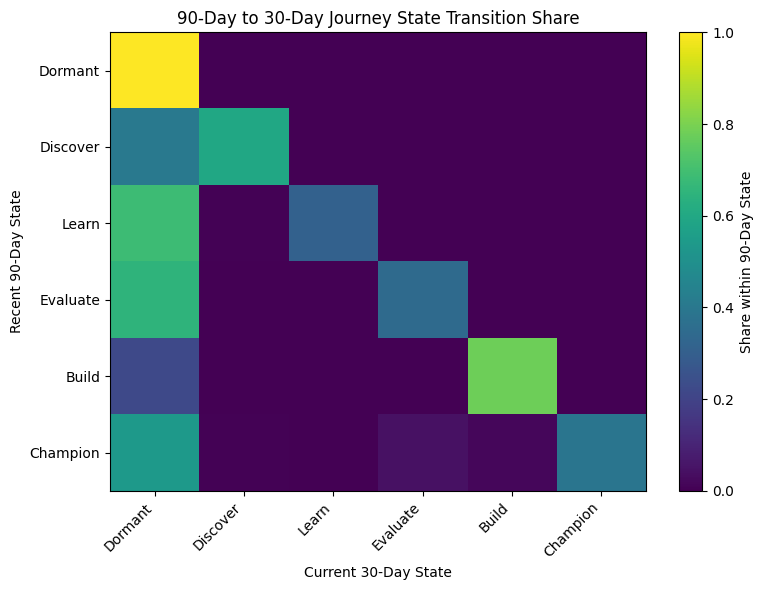

In [54]:
transition_matrix = con.execute("""
SELECT state_90d, state_30d, COUNT(*) AS developers
FROM dev_transition_v1
GROUP BY 1,2
ORDER BY 1,2
""").fetchdf()

heatmap_df = transition_matrix.pivot(index="state_90d", columns="state_30d", values="developers").fillna(0)
state_order = ["Dormant", "Discover", "Learn", "Evaluate", "Build", "Champion"]
heatmap_df = heatmap_df.reindex(index=state_order, columns=state_order, fill_value=0)
heatmap_pct = heatmap_df.div(heatmap_df.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)

plt.figure(figsize=(8, 6))
plt.imshow(heatmap_pct, aspect="auto")
plt.xticks(range(len(heatmap_pct.columns)), heatmap_pct.columns, rotation=45, ha="right")
plt.yticks(range(len(heatmap_pct.index)), heatmap_pct.index)
plt.title("90-Day to 30-Day Journey State Transition Share")
plt.xlabel("Current 30-Day State")
plt.ylabel("Recent 90-Day State")
plt.colorbar(label="Share within 90-Day State")
plt.tight_layout()
plt.show()


## 10. Final developer profile output

This table combines the project's interpretable baseline outputs:
- current journey state
- persona / lane
- transition label
- trajectory label

Later, UMAP + HDBSCAN can add behavioral segment, and HMM can add probabilistic state inference.


In [55]:
con.execute("""
CREATE OR REPLACE TABLE dev_profile_final_v1 AS
SELECT
    u.developer_id,
    p.persona,
    p.persona_confidence,
    p.persona_confidence_tier,
    p.mixed_persona_flag,
    d30.journey_state AS current_journey_state_30d,
    d30.journey_state_confidence AS current_journey_state_confidence,
    d90.journey_state AS recent_journey_state_90d,
    d180.journey_state AS historical_journey_state_180d,
    t.transition_90d_to_30d,
    t.trajectory_label,
    d30.activity_count_total AS activity_count_30d,
    d90.activity_count_total AS activity_count_90d,
    d180.activity_count_total AS activity_count_180d,
    d30.days_since_last_activity,
    d30.high_effort_count AS high_effort_count_30d,
    d30.unique_activity_types AS unique_activity_types_30d
FROM developer_universe_v1 u
LEFT JOIN dev_persona_v1 p USING (developer_id)
LEFT JOIN dev_profile_30d_v1 d30 USING (developer_id)
LEFT JOIN dev_profile_90d_v1 d90 USING (developer_id)
LEFT JOIN dev_profile_180d_v1 d180 USING (developer_id)
LEFT JOIN dev_transition_v1 t USING (developer_id)
""")

display(con.execute("""
SELECT *
FROM dev_profile_final_v1
LIMIT 50
""").fetchdf())


100% ▕██████████████████████████████████████▏ (00:00:03.47 elapsed)     


,developer_id,persona,persona_confidence,persona_confidence_tier,mixed_persona_flag,current_journey_state_30d,current_journey_state_confidence,recent_journey_state_90d,historical_journey_state_180d,transition_90d_to_30d,trajectory_label,activity_count_30d,activity_count_90d,activity_count_180d,days_since_last_activity,high_effort_count_30d,unique_activity_types_30d
0,9075523,Unknown,0.0,Unknown,0,Dormant,1.0,Dormant,Dormant,Stable,Plateaued,0,0,0,<NA>,0.0,0
1,7355323,Unknown,0.0,Unknown,0,Dormant,1.0,Dormant,Dormant,Stable,Plateaued,0,0,0,<NA>,0.0,0
2,6693214,Unknown,0.0,Unknown,0,Dormant,1.0,Dormant,Dormant,Stable,Plateaued,0,0,0,<NA>,0.0,0
3,7078038,Unknown,0.0,Unknown,0,Dormant,1.0,Dormant,Dormant,Stable,Plateaued,0,0,0,<NA>,0.0,0
4,9553051,GenAI,1.0,High,0,Dormant,1.0,Dormant,Learn,Stable,Mixed / stable,0,0,4,<NA>,0.0,0
5,7961333,Unknown,0.0,Unknown,0,Dormant,1.0,Dormant,Dormant,Stable,Plateaued,0,0,0,<NA>,0.0,0
6,8246030,Unknown,0.0,Unknown,0,Dormant,1.0,Dormant,Dormant,Stable,Plateaued,0,0,0,<NA>,0.0,0
7,8179544,Unknown,0.0,Unknown,0,Dormant,1.0,Dormant,Dormant,Stable,Plateaued,0,0,0,<NA>,0.0,0
8,7935494,Unknown,0.0,Unknown,0,Dormant,1.0,Dormant,Dormant,Stable,Plateaued,0,0,0,<NA>,0.0,0
9,9951982,CUDA,1.0,High,0,Dormant,1.0,Discover,Discover,Churned,Newly dormant,0,1,1,<NA>,0.0,0


### Validation: final profile completeness


In [56]:
display(con.execute("""
SELECT
    COUNT(*) AS rows,
    COUNT(DISTINCT developer_id) AS developers,
    SUM(CASE WHEN persona IS NULL THEN 1 ELSE 0 END) AS missing_persona,
    SUM(CASE WHEN current_journey_state_30d IS NULL THEN 1 ELSE 0 END) AS missing_current_state,
    SUM(CASE WHEN transition_90d_to_30d IS NULL THEN 1 ELSE 0 END) AS missing_transition
FROM dev_profile_final_v1
""").fetchdf())

display(con.execute("""
SELECT persona, current_journey_state_30d, COUNT(*) AS developers
FROM dev_profile_final_v1
GROUP BY 1,2
ORDER BY developers DESC
LIMIT 30
""").fetchdf())


,rows,developers,missing_persona,missing_current_state,missing_transition
0,9381508,9381508,0.0,0.0,0.0


,persona,current_journey_state_30d,developers
0,Unknown,Dormant,8160384
1,GenAI,Dormant,359500
2,CUDA,Dormant,251193
3,GenAI,Discover,176930
4,Other,Dormant,90139
5,GenAI,Build,87172
6,Robotics,Dormant,54457
7,Learning_Community,Dormant,26318
8,CUDA,Evaluate,24681
9,GenAI,Learn,22955


## 11. Optional: weekly sequence features for later HMM

This is not used for the baseline journey state. It creates non-overlapping weekly observations that can be used for HMM modeling later.


In [57]:
con.execute("""
CREATE OR REPLACE TABLE dev_weekly_features_v1 AS
WITH weekly AS (
    SELECT
        developer_id,
        DATE_TRUNC('week', activity_date) AS week_start,
        COUNT(*) AS activity_count_total,
        SUM(activity_score) AS activity_score_sum,
        SUM(CASE WHEN journey_signal = 'Discover' THEN 1 ELSE 0 END) AS discover_count,
        SUM(CASE WHEN journey_signal = 'Learn' THEN 1 ELSE 0 END) AS learn_count,
        SUM(CASE WHEN journey_signal = 'Evaluate' THEN 1 ELSE 0 END) AS evaluate_count,
        SUM(CASE WHEN journey_signal = 'Build' THEN 1 ELSE 0 END) AS build_count,
        SUM(CASE WHEN journey_signal = 'Champion' THEN 1 ELSE 0 END) AS champion_count,
        SUM(CASE WHEN effort_level = 'High' THEN 1 ELSE 0 END) AS high_effort_count,
        COUNT(DISTINCT activity) AS unique_activity_types,
        SUM(CASE WHEN persona_hint = 'CUDA' THEN activity_score ELSE 0 END) AS cuda_score,
        SUM(CASE WHEN persona_hint = 'GenAI' THEN activity_score ELSE 0 END) AS genai_score,
        SUM(CASE WHEN persona_hint = 'Robotics' THEN activity_score ELSE 0 END) AS robotics_score,
        SUM(CASE WHEN persona_hint = 'Simulation' THEN activity_score ELSE 0 END) AS simulation_score
    FROM activity_ontology_v1
    GROUP BY 1,2
)
SELECT
    *,
    LOG(1 + activity_count_total) AS activity_count_log,
    LOG(1 + activity_score_sum) AS activity_score_log,
    LOG(1 + evaluate_count) AS evaluate_count_log,
    LOG(1 + build_count) AS build_count_log,
    LOG(1 + champion_count) AS champion_count_log
FROM weekly
""")

display(con.execute("""
SELECT
    COUNT(*) AS developer_weeks,
    COUNT(DISTINCT developer_id) AS developers,
    MIN(week_start) AS min_week,
    MAX(week_start) AS max_week
FROM dev_weekly_features_v1
""").fetchdf())


100% ▕██████████████████████████████████████▏ (00:00:16.94 elapsed)     


,developer_weeks,developers,min_week,max_week
0,14908480,7660278,2019-12-30,2026-03-09


In [58]:
ONTOLOGY_TABLE = "activity_ontology_v1"
DEVELOPER_UNIVERSE_TABLE = "developer_universe_v1"

STATE_ORDER = ["Dormant", "Discover", "Learn", "Evaluate", "Build", "Champion"]
STATE_RANK = {s: i for i, s in enumerate(STATE_ORDER)}


## 1. Confirm required upstream tables

Run the earlier feature-engineering notebook first. This continuation expects `activity_ontology_v1` and `developer_universe_v1` to exist.


In [59]:
tables = con.execute("SHOW TABLES").fetchdf()
display(tables)

available = set(tables.iloc[:, 0].astype(str))
required = {ONTOLOGY_TABLE, DEVELOPER_UNIVERSE_TABLE}
missing = required - available
if missing:
    raise ValueError(f"Missing required table(s): {missing}. Run the validated feature engineering notebook first.")

for table in sorted(required):
    print(table)
    display(con.execute(f"SELECT COUNT(*) AS rows FROM {table}").fetchdf())


,name
0,activity_base
1,activity_clean
2,activity_enriched_v1
3,activity_final
4,activity_ontology_v1
5,activity_raw
6,activity_score_mapping_clean
7,activity_score_mapping_raw
8,activity_work
9,contact_clean


activity_ontology_v1


,rows
0,69347501


developer_universe_v1


,rows
0,9381508


## 2. Dataset date range and anchor date

Important: do **not** use `CURRENT_DATE` for this project because the data ends before today. All windows should use the observed max date in the dataset unless you intentionally set a business anchor date.


In [60]:
date_summary = con.execute(f"""
SELECT
    MIN(activity_date) AS min_activity_date,
    MAX(activity_date) AS max_activity_date,
    DATE_DIFF('day', MIN(activity_date), MAX(activity_date)) + 1 AS covered_days,
    COUNT(*) AS activity_rows,
    COUNT(DISTINCT developer_id) AS active_developers
FROM {ONTOLOGY_TABLE}
""").fetchdf()
display(date_summary)

ANCHOR_DATE = con.execute(f"SELECT MAX(activity_date) FROM {ONTOLOGY_TABLE}").fetchone()[0]
print("Using anchor date:", ANCHOR_DATE)


,min_activity_date,max_activity_date,covered_days,activity_rows,active_developers
0,2020-01-01,2026-03-12,2263,69347501,7660278


Using anchor date: 2026-03-12


## 3. Lifetime developer features

Persona should be more stable than current journey state. Therefore, use all-time activity for persona and historical context, while keeping journey state as 30/90/180-day behavior.


In [61]:
con.execute(f"""
CREATE OR REPLACE TABLE dev_features_lifetime_v1 AS
SELECT
    u.developer_id,
    COALESCE(a.activity_count_total, 0) AS lifetime_activity_count_total,
    COALESCE(a.activity_score_sum, 0.0) AS lifetime_activity_score_sum,
    COALESCE(a.activity_score_avg, 0.0) AS lifetime_activity_score_avg,
    a.first_activity_date,
    a.last_activity_date,
    DATE_DIFF('day', a.first_activity_date, a.last_activity_date) AS observed_active_span_days,
    DATE_DIFF('day', a.first_activity_date, (SELECT MAX(activity_date) FROM {ONTOLOGY_TABLE})) AS days_since_first_activity,
    DATE_DIFF('day', a.last_activity_date, (SELECT MAX(activity_date) FROM {ONTOLOGY_TABLE})) AS days_since_last_activity_lifetime,
    COALESCE(a.unique_activity_days, 0) AS lifetime_unique_activity_days,
    COALESCE(a.unique_activity_types, 0) AS lifetime_unique_activity_types,
    COALESCE(a.unique_journey_signals, 0) AS lifetime_unique_journey_signals,
    COALESCE(a.unique_modalities, 0) AS lifetime_unique_modalities,
    COALESCE(a.discover_count, 0) AS lifetime_discover_count,
    COALESCE(a.learn_count, 0) AS lifetime_learn_count,
    COALESCE(a.evaluate_count, 0) AS lifetime_evaluate_count,
    COALESCE(a.build_count, 0) AS lifetime_build_count,
    COALESCE(a.champion_count, 0) AS lifetime_champion_count,
    COALESCE(a.high_effort_count, 0) AS lifetime_high_effort_count,
    COALESCE(a.cuda_score, 0.0) AS lifetime_cuda_score,
    COALESCE(a.genai_score, 0.0) AS lifetime_genai_score,
    COALESCE(a.robotics_score, 0.0) AS lifetime_robotics_score,
    COALESCE(a.simulation_score, 0.0) AS lifetime_simulation_score,
    COALESCE(a.learning_community_score, 0.0) AS lifetime_learning_community_score,
    COALESCE(a.other_persona_score, 0.0) AS lifetime_other_persona_score
FROM {DEVELOPER_UNIVERSE_TABLE} u
LEFT JOIN (
    SELECT
        developer_id,
        COUNT(*) AS activity_count_total,
        SUM(activity_score) AS activity_score_sum,
        AVG(activity_score) AS activity_score_avg,
        MIN(activity_date) AS first_activity_date,
        MAX(activity_date) AS last_activity_date,
        COUNT(DISTINCT activity_date) AS unique_activity_days,
        COUNT(DISTINCT activity) AS unique_activity_types,
        COUNT(DISTINCT journey_signal) AS unique_journey_signals,
        COUNT(DISTINCT modality) AS unique_modalities,
        SUM(CASE WHEN journey_signal = 'Discover' THEN 1 ELSE 0 END) AS discover_count,
        SUM(CASE WHEN journey_signal = 'Learn' THEN 1 ELSE 0 END) AS learn_count,
        SUM(CASE WHEN journey_signal = 'Evaluate' THEN 1 ELSE 0 END) AS evaluate_count,
        SUM(CASE WHEN journey_signal = 'Build' THEN 1 ELSE 0 END) AS build_count,
        SUM(CASE WHEN journey_signal = 'Champion' THEN 1 ELSE 0 END) AS champion_count,
        SUM(CASE WHEN effort_level = 'High' THEN 1 ELSE 0 END) AS high_effort_count,
        SUM(CASE WHEN persona_hint = 'CUDA' THEN activity_score ELSE 0 END) AS cuda_score,
        SUM(CASE WHEN persona_hint = 'GenAI' THEN activity_score ELSE 0 END) AS genai_score,
        SUM(CASE WHEN persona_hint = 'Robotics' THEN activity_score ELSE 0 END) AS robotics_score,
        SUM(CASE WHEN persona_hint = 'Simulation' THEN activity_score ELSE 0 END) AS simulation_score,
        SUM(CASE WHEN persona_hint = 'Learning_Community' THEN activity_score ELSE 0 END) AS learning_community_score,
        SUM(CASE WHEN persona_hint IN ('Other', 'Unknown') OR persona_hint IS NULL THEN activity_score ELSE 0 END) AS other_persona_score
    FROM {ONTOLOGY_TABLE}
    GROUP BY developer_id
) a USING (developer_id)
""")

display(con.execute("""
SELECT
    COUNT(*) AS rows,
    COUNT(DISTINCT developer_id) AS developers,
    SUM(CASE WHEN lifetime_activity_count_total = 0 THEN 1 ELSE 0 END) AS never_active_developers,
    MIN(first_activity_date) AS min_first_activity,
    MAX(last_activity_date) AS max_last_activity,
    MAX(lifetime_activity_count_total) AS max_lifetime_activity_count
FROM dev_features_lifetime_v1
""").fetchdf())


100% ▕██████████████████████████████████████▏ (00:00:34.27 elapsed)     


,rows,developers,never_active_developers,min_first_activity,max_last_activity,max_lifetime_activity_count
0,9381508,9381508,1721230.0,2020-01-01,2026-03-12,2027375


### Validation: lifetime feature distributions and outliers

Extreme users are expected in this dataset. Do not drop them automatically. Flag, cap, or log-transform before clustering/modeling.


In [62]:
display(con.execute("""
SELECT
    approx_quantile(lifetime_activity_count_total, 0.50) AS p50_activity,
    approx_quantile(lifetime_activity_count_total, 0.90) AS p90_activity,
    approx_quantile(lifetime_activity_count_total, 0.99) AS p99_activity,
    approx_quantile(lifetime_activity_count_total, 0.999) AS p999_activity,
    MAX(lifetime_activity_count_total) AS max_activity
FROM dev_features_lifetime_v1
""").fetchdf())

display(con.execute("""
SELECT developer_id, lifetime_activity_count_total, lifetime_activity_score_sum,
       first_activity_date, last_activity_date, lifetime_unique_activity_types,
       lifetime_build_count, lifetime_champion_count
FROM dev_features_lifetime_v1
ORDER BY lifetime_activity_count_total DESC
LIMIT 25
""").fetchdf())


,p50_activity,p90_activity,p99_activity,p999_activity,max_activity
0,2,7,115,594,2027375


,developer_id,lifetime_activity_count_total,lifetime_activity_score_sum,first_activity_date,last_activity_date,lifetime_unique_activity_types,lifetime_build_count,lifetime_champion_count
0,5903679,2027375,10015777.0,2021-03-04,2026-03-12,2,2027374.0,0.0
1,5886356,789400,3946993.0,2024-03-04,2026-03-12,4,789395.0,0.0
2,3931685,187095,935275.0,2023-07-04,2026-03-03,1,187095.0,0.0
3,1303597,151947,450792.0,2020-01-02,2026-03-08,3,0.0,0.0
4,2028858,142980,714580.0,2022-03-12,2026-03-12,1,142980.0,0.0
5,6309430,121950,235235.0,2020-03-20,2026-03-11,5,121282.0,0.0
6,4634152,107089,180756.0,2022-04-27,2025-11-13,1,107089.0,0.0
7,6125204,68992,344961.0,2020-04-17,2026-02-12,9,68888.0,2.0
8,4833930,55061,275414.0,2024-05-24,2024-11-06,2,55060.0,0.0
9,225774,53677,268041.0,2021-03-11,2022-10-04,1,53677.0,0.0


## 4. Replace persona with lifetime persona

This fixes the issue where most users can become `Unknown` if persona is only based on the last 180 days.


In [63]:
con.execute("""
CREATE OR REPLACE TABLE dev_persona_lifetime_v1 AS
WITH base AS (
    SELECT
        developer_id,
        lifetime_cuda_score AS cuda_score,
        lifetime_genai_score AS genai_score,
        lifetime_robotics_score AS robotics_score,
        lifetime_simulation_score AS simulation_score,
        lifetime_learning_community_score AS learning_community_score,
        lifetime_other_persona_score AS other_score,
        lifetime_cuda_score + lifetime_genai_score + lifetime_robotics_score +
        lifetime_simulation_score + lifetime_learning_community_score + lifetime_other_persona_score AS total_persona_score
    FROM dev_features_lifetime_v1
),
norm AS (
    SELECT
        *,
        cuda_score / NULLIF(total_persona_score, 0) AS cuda_norm,
        genai_score / NULLIF(total_persona_score, 0) AS genai_norm,
        robotics_score / NULLIF(total_persona_score, 0) AS robotics_norm,
        simulation_score / NULLIF(total_persona_score, 0) AS simulation_norm,
        learning_community_score / NULLIF(total_persona_score, 0) AS learning_community_norm,
        other_score / NULLIF(total_persona_score, 0) AS other_norm
    FROM base
),
long_scores AS (
    SELECT developer_id, 'CUDA' AS persona, COALESCE(cuda_norm, 0) AS norm_score FROM norm
    UNION ALL SELECT developer_id, 'GenAI', COALESCE(genai_norm, 0) FROM norm
    UNION ALL SELECT developer_id, 'Robotics', COALESCE(robotics_norm, 0) FROM norm
    UNION ALL SELECT developer_id, 'Simulation', COALESCE(simulation_norm, 0) FROM norm
    UNION ALL SELECT developer_id, 'Learning_Community', COALESCE(learning_community_norm, 0) FROM norm
    UNION ALL SELECT developer_id, 'Other', COALESCE(other_norm, 0) FROM norm
),
ranked AS (
    SELECT
        *,
        ROW_NUMBER() OVER (PARTITION BY developer_id ORDER BY norm_score DESC, persona) AS persona_rank,
        LEAD(norm_score) OVER (PARTITION BY developer_id ORDER BY norm_score DESC, persona) AS second_norm_score
    FROM long_scores
)
SELECT
    n.developer_id,
    CASE WHEN n.total_persona_score = 0 THEN 'Unknown' ELSE r.persona END AS persona,
    CASE WHEN n.total_persona_score = 0 THEN 0 ELSE r.norm_score END AS persona_confidence,
    CASE
        WHEN n.total_persona_score = 0 THEN 'Unknown'
        WHEN r.norm_score >= 0.70 THEN 'High'
        WHEN r.norm_score >= 0.45 THEN 'Medium'
        ELSE 'Low'
    END AS persona_confidence_tier,
    CASE
        WHEN n.total_persona_score = 0 THEN 0
        WHEN ABS(r.norm_score - COALESCE(r.second_norm_score, 0)) <= 0.15 THEN 1
        ELSE 0
    END AS mixed_persona_flag,
    n.cuda_norm,
    n.genai_norm,
    n.robotics_norm,
    n.simulation_norm,
    n.learning_community_norm,
    n.other_norm,
    n.total_persona_score
FROM norm n
LEFT JOIN ranked r
    ON n.developer_id = r.developer_id
   AND r.persona_rank = 1
""")

display(con.execute("""
SELECT persona, persona_confidence_tier, mixed_persona_flag,
       COUNT(*) AS developers,
       COUNT(*) * 1.0 / SUM(COUNT(*)) OVER () AS pct
FROM dev_persona_lifetime_v1
GROUP BY 1,2,3
ORDER BY developers DESC
""").fetchdf())


100% ▕██████████████████████████████████████▏ (00:00:02.62 elapsed)     


,persona,persona_confidence_tier,mixed_persona_flag,developers,pct
0,CUDA,High,0,2970863,0.316672
1,Unknown,Unknown,0,1781784,0.189925
2,GenAI,High,0,1701253,0.181341
3,Other,High,0,1107462,0.118047
4,Robotics,High,0,500810,0.053383
5,Simulation,High,0,415032,0.044239
6,Learning_Community,High,0,367599,0.039183
7,CUDA,Medium,0,106598,0.011363
8,CUDA,Medium,1,95566,0.010187
9,Robotics,Medium,0,65298,0.006960


## 5. Create non-overlapping 30-day periods across the whole dataset

This is the answer to: “Should we have multiple 30-day periods for the whole data?”

Yes, but store them in a separate panel table. This table is **not** one row per developer. It is one row per developer-period with activity in that period.


In [64]:
con.execute(f"""
CREATE OR REPLACE TABLE calendar_30d_periods_v1 AS
WITH bounds AS (
    SELECT
        MIN(activity_date) AS min_date,
        MAX(activity_date) AS max_date
    FROM {ONTOLOGY_TABLE}
),
periods AS (
    SELECT
        period_index,
        min_date + CAST(period_index * 30 AS INTEGER) AS period_start,
        LEAST(min_date + CAST((period_index + 1) * 30 - 1 AS INTEGER), max_date) AS period_end
    FROM bounds,
    RANGE(
        0,
        CAST(CEIL((DATE_DIFF('day', min_date, max_date) + 1) / 30.0) AS BIGINT)
    ) AS r(period_index)
)
SELECT *
FROM periods
ORDER BY period_index
""")

display(con.execute("""
SELECT COUNT(*) AS periods,
       MIN(period_start) AS first_period_start,
       MAX(period_end) AS last_period_end
FROM calendar_30d_periods_v1
""").fetchdf())

display(con.execute("SELECT * FROM calendar_30d_periods_v1 ORDER BY period_index LIMIT 10").fetchdf())
display(con.execute("SELECT * FROM calendar_30d_periods_v1 ORDER BY period_index DESC LIMIT 10").fetchdf())


,periods,first_period_start,last_period_end
0,76,2020-01-01,2026-03-12


,period_index,period_start,period_end
0,0,2020-01-01,2020-01-30
1,1,2020-01-31,2020-02-29
2,2,2020-03-01,2020-03-30
3,3,2020-03-31,2020-04-29
4,4,2020-04-30,2020-05-29
5,5,2020-05-30,2020-06-28
6,6,2020-06-29,2020-07-28
7,7,2020-07-29,2020-08-27
8,8,2020-08-28,2020-09-26
9,9,2020-09-27,2020-10-26


,period_index,period_start,period_end
0,75,2026-02-28,2026-03-12
1,74,2026-01-29,2026-02-27
2,73,2025-12-30,2026-01-28
3,72,2025-11-30,2025-12-29
4,71,2025-10-31,2025-11-29
5,70,2025-10-01,2025-10-30
6,69,2025-09-01,2025-09-30
7,68,2025-08-02,2025-08-31
8,67,2025-07-03,2025-08-01
9,66,2025-06-03,2025-07-02


## 6. Non-overlapping 30-day activity features

This table measures true activity inside each discrete 30-day slice. No activity row appears in more than one period.


In [65]:
con.execute(f"""
CREATE OR REPLACE TABLE dev_period_activity_30d_v1 AS
SELECT
    a.developer_id,
    p.period_index,
    p.period_start,
    p.period_end,
    COUNT(*) AS activity_count_total,
    SUM(a.activity_score) AS activity_score_sum,
    AVG(a.activity_score) AS activity_score_avg,
    COUNT(DISTINCT a.activity_date) AS unique_activity_days,
    COUNT(DISTINCT a.activity) AS unique_activity_types,
    COUNT(DISTINCT a.journey_signal) AS unique_journey_signals,
    COUNT(DISTINCT a.persona_hint) AS unique_persona_hints,
    COUNT(DISTINCT a.modality) AS unique_modalities,
    SUM(CASE WHEN a.journey_signal = 'Discover' THEN 1 ELSE 0 END) AS discover_count,
    SUM(CASE WHEN a.journey_signal = 'Learn' THEN 1 ELSE 0 END) AS learn_count,
    SUM(CASE WHEN a.journey_signal = 'Evaluate' THEN 1 ELSE 0 END) AS evaluate_count,
    SUM(CASE WHEN a.journey_signal = 'Build' THEN 1 ELSE 0 END) AS build_count,
    SUM(CASE WHEN a.journey_signal = 'Champion' THEN 1 ELSE 0 END) AS champion_count,
    SUM(CASE WHEN a.effort_level = 'Passive' THEN 1 ELSE 0 END) AS passive_count,
    SUM(CASE WHEN a.effort_level = 'Moderate' THEN 1 ELSE 0 END) AS moderate_count,
    SUM(CASE WHEN a.effort_level = 'High' THEN 1 ELSE 0 END) AS high_effort_count,
    SUM(CASE WHEN a.journey_signal = 'Discover' THEN a.activity_score ELSE 0 END) AS discover_score,
    SUM(CASE WHEN a.journey_signal = 'Learn' THEN a.activity_score ELSE 0 END) AS learn_score,
    SUM(CASE WHEN a.journey_signal = 'Evaluate' THEN a.activity_score ELSE 0 END) AS evaluate_score,
    SUM(CASE WHEN a.journey_signal = 'Build' THEN a.activity_score ELSE 0 END) AS build_score,
    SUM(CASE WHEN a.journey_signal = 'Champion' THEN a.activity_score ELSE 0 END) AS champion_score,
    SUM(CASE WHEN a.persona_hint = 'CUDA' THEN a.activity_score ELSE 0 END) AS cuda_score,
    SUM(CASE WHEN a.persona_hint = 'GenAI' THEN a.activity_score ELSE 0 END) AS genai_score,
    SUM(CASE WHEN a.persona_hint = 'Robotics' THEN a.activity_score ELSE 0 END) AS robotics_score,
    SUM(CASE WHEN a.persona_hint = 'Simulation' THEN a.activity_score ELSE 0 END) AS simulation_score,
    SUM(CASE WHEN a.persona_hint = 'Learning_Community' THEN a.activity_score ELSE 0 END) AS learning_community_score,
    MIN(a.activity_date) AS first_activity_date_in_period,
    MAX(a.activity_date) AS last_activity_date_in_period
FROM {ONTOLOGY_TABLE} a
JOIN calendar_30d_periods_v1 p
  ON a.activity_date BETWEEN p.period_start AND p.period_end
GROUP BY 1,2,3,4
""")

display(con.execute("""
SELECT
    COUNT(*) AS developer_period_rows_with_activity,
    COUNT(DISTINCT developer_id) AS active_developers,
    COUNT(DISTINCT period_index) AS periods_with_activity,
    SUM(activity_count_total) AS represented_activity_rows
FROM dev_period_activity_30d_v1
""").fetchdf())

# Validate no double counting against the ontology table.
display(con.execute(f"""
SELECT
    (SELECT COUNT(*) FROM {ONTOLOGY_TABLE}) AS ontology_rows,
    (SELECT SUM(activity_count_total) FROM dev_period_activity_30d_v1) AS summed_period_rows,
    (SELECT COUNT(*) FROM {ONTOLOGY_TABLE}) - (SELECT SUM(activity_count_total) FROM dev_period_activity_30d_v1) AS row_difference
""").fetchdf())


100% ▕██████████████████████████████████████▏ (00:01:28.52 elapsed)     


,developer_period_rows_with_activity,active_developers,periods_with_activity,represented_activity_rows
0,12618831,7660278,76,69347501.0


,ontology_rows,summed_period_rows,row_difference
0,69347501,69347501.0,0.0


### Validation: period uniqueness and activity distribution


In [66]:
display(con.execute("""
SELECT
    COUNT(*) AS rows,
    COUNT(DISTINCT developer_id || '|' || CAST(period_index AS VARCHAR)) AS distinct_developer_periods,
    COUNT(*) - COUNT(DISTINCT developer_id || '|' || CAST(period_index AS VARCHAR)) AS duplicate_developer_periods
FROM dev_period_activity_30d_v1
""").fetchdf())

display(con.execute("""
SELECT
    period_index,
    period_start,
    period_end,
    COUNT(DISTINCT developer_id) AS active_developers,
    SUM(activity_count_total) AS activity_rows,
    AVG(activity_count_total) AS avg_activity_per_active_dev,
    MAX(activity_count_total) AS max_activity_for_one_dev
FROM dev_period_activity_30d_v1
GROUP BY 1,2,3
ORDER BY period_index
""").fetchdf())


,rows,distinct_developer_periods,duplicate_developer_periods
0,12618831,12618831,0


,period_index,period_start,period_end,active_developers,activity_rows,avg_activity_per_active_dev,max_activity_for_one_dev
0,0,2020-01-01,2020-01-30,83726,564055.0,6.736916,1130
1,1,2020-01-31,2020-02-29,89782,581959.0,6.481912,1203
2,2,2020-03-01,2020-03-30,103059,616885.0,5.985746,1500
3,3,2020-03-31,2020-04-29,119381,678122.0,5.680318,1214
4,4,2020-04-30,2020-05-29,118233,718376.0,6.075935,1078
5,5,2020-05-30,2020-06-28,112950,703713.0,6.230305,1472
6,6,2020-06-29,2020-07-28,109031,746320.0,6.845026,1861
7,7,2020-07-29,2020-08-27,103501,666184.0,6.436498,1768
8,8,2020-08-28,2020-09-26,112753,665772.0,5.904694,3169
9,9,2020-09-27,2020-10-26,132826,870971.0,6.557233,2794


## 7. As-of trailing 30/90/180-day features at every 30-day anchor

This table gives a rolling snapshot every 30 days across the full data range.

To avoid a massive all-developer x all-period table, this version includes developers who were active in the trailing 180-day lookback for each period. Developers with no activity in the trailing 180 days are Dormant and can be added later only if needed for a full production scoring table.


In [67]:
con.execute("""
CREATE OR REPLACE TABLE dev_asof_features_30_90_180_v1 AS
WITH developer_periods AS (
    -- Include a developer at period t if they had activity in t, t-1, ..., t-5.
    -- Since each period is 30 days, this approximates trailing 180 days.
    SELECT DISTINCT
        d.developer_id,
        p.period_index AS anchor_period_index,
        p.period_start AS anchor_period_start,
        p.period_end AS anchor_period_end
    FROM calendar_30d_periods_v1 p
    JOIN dev_period_activity_30d_v1 d
      ON d.period_index BETWEEN p.period_index - 5 AND p.period_index
),
joined AS (
    SELECT
        dp.developer_id,
        dp.anchor_period_index,
        dp.anchor_period_start,
        dp.anchor_period_end,
        pa.period_index,
        pa.activity_count_total,
        pa.activity_score_sum,
        pa.unique_activity_days,
        pa.unique_activity_types,
        pa.unique_journey_signals,
        pa.unique_modalities,
        pa.discover_count,
        pa.learn_count,
        pa.evaluate_count,
        pa.build_count,
        pa.champion_count,
        pa.passive_count,
        pa.moderate_count,
        pa.high_effort_count,
        pa.discover_score,
        pa.learn_score,
        pa.evaluate_score,
        pa.build_score,
        pa.champion_score,
        pa.cuda_score,
        pa.genai_score,
        pa.robotics_score,
        pa.simulation_score,
        pa.learning_community_score,
        pa.last_activity_date_in_period
    FROM developer_periods dp
    LEFT JOIN dev_period_activity_30d_v1 pa
      ON dp.developer_id = pa.developer_id
     AND pa.period_index BETWEEN dp.anchor_period_index - 5 AND dp.anchor_period_index
)
SELECT
    developer_id,
    anchor_period_index,
    anchor_period_start,
    anchor_period_end,

    -- trailing 30 days: current 30-day period only
    SUM(CASE WHEN period_index = anchor_period_index THEN activity_count_total ELSE 0 END) AS activity_count_30d,
    SUM(CASE WHEN period_index = anchor_period_index THEN activity_score_sum ELSE 0 END) AS activity_score_30d,
    SUM(CASE WHEN period_index = anchor_period_index THEN discover_count ELSE 0 END) AS discover_count_30d,
    SUM(CASE WHEN period_index = anchor_period_index THEN learn_count ELSE 0 END) AS learn_count_30d,
    SUM(CASE WHEN period_index = anchor_period_index THEN evaluate_count ELSE 0 END) AS evaluate_count_30d,
    SUM(CASE WHEN period_index = anchor_period_index THEN build_count ELSE 0 END) AS build_count_30d,
    SUM(CASE WHEN period_index = anchor_period_index THEN champion_count ELSE 0 END) AS champion_count_30d,
    SUM(CASE WHEN period_index = anchor_period_index THEN high_effort_count ELSE 0 END) AS high_effort_count_30d,

    -- trailing 90 days: current + previous 2 periods
    SUM(CASE WHEN period_index BETWEEN anchor_period_index - 2 AND anchor_period_index THEN activity_count_total ELSE 0 END) AS activity_count_90d,
    SUM(CASE WHEN period_index BETWEEN anchor_period_index - 2 AND anchor_period_index THEN activity_score_sum ELSE 0 END) AS activity_score_90d,
    SUM(CASE WHEN period_index BETWEEN anchor_period_index - 2 AND anchor_period_index THEN discover_count ELSE 0 END) AS discover_count_90d,
    SUM(CASE WHEN period_index BETWEEN anchor_period_index - 2 AND anchor_period_index THEN learn_count ELSE 0 END) AS learn_count_90d,
    SUM(CASE WHEN period_index BETWEEN anchor_period_index - 2 AND anchor_period_index THEN evaluate_count ELSE 0 END) AS evaluate_count_90d,
    SUM(CASE WHEN period_index BETWEEN anchor_period_index - 2 AND anchor_period_index THEN build_count ELSE 0 END) AS build_count_90d,
    SUM(CASE WHEN period_index BETWEEN anchor_period_index - 2 AND anchor_period_index THEN champion_count ELSE 0 END) AS champion_count_90d,
    SUM(CASE WHEN period_index BETWEEN anchor_period_index - 2 AND anchor_period_index THEN high_effort_count ELSE 0 END) AS high_effort_count_90d,

    -- trailing 180 days: current + previous 5 periods
    SUM(CASE WHEN period_index BETWEEN anchor_period_index - 5 AND anchor_period_index THEN activity_count_total ELSE 0 END) AS activity_count_180d,
    SUM(CASE WHEN period_index BETWEEN anchor_period_index - 5 AND anchor_period_index THEN activity_score_sum ELSE 0 END) AS activity_score_180d,
    SUM(CASE WHEN period_index BETWEEN anchor_period_index - 5 AND anchor_period_index THEN discover_count ELSE 0 END) AS discover_count_180d,
    SUM(CASE WHEN period_index BETWEEN anchor_period_index - 5 AND anchor_period_index THEN learn_count ELSE 0 END) AS learn_count_180d,
    SUM(CASE WHEN period_index BETWEEN anchor_period_index - 5 AND anchor_period_index THEN evaluate_count ELSE 0 END) AS evaluate_count_180d,
    SUM(CASE WHEN period_index BETWEEN anchor_period_index - 5 AND anchor_period_index THEN build_count ELSE 0 END) AS build_count_180d,
    SUM(CASE WHEN period_index BETWEEN anchor_period_index - 5 AND anchor_period_index THEN champion_count ELSE 0 END) AS champion_count_180d,
    SUM(CASE WHEN period_index BETWEEN anchor_period_index - 5 AND anchor_period_index THEN high_effort_count ELSE 0 END) AS high_effort_count_180d,

    MAX(last_activity_date_in_period) AS last_activity_date_asof,
    DATE_DIFF('day', MAX(last_activity_date_in_period), anchor_period_end) AS days_since_last_activity_asof,

    COUNT(DISTINCT CASE WHEN activity_count_total > 0 THEN period_index END) AS active_30d_periods_in_180d,
    SUM(COALESCE(unique_activity_types, 0)) AS summed_unique_activity_types_180d,
    SUM(COALESCE(unique_modalities, 0)) AS summed_unique_modalities_180d
FROM joined
GROUP BY 1,2,3,4
""")

display(con.execute("""
SELECT
    COUNT(*) AS rows,
    COUNT(DISTINCT developer_id) AS developers,
    COUNT(DISTINCT anchor_period_index) AS anchor_periods,
    MIN(anchor_period_start) AS first_anchor_start,
    MAX(anchor_period_end) AS last_anchor_end
FROM dev_asof_features_30_90_180_v1
""").fetchdf())


100% ▕██████████████████████████████████████▏ (00:00:56.30 elapsed)     


,rows,developers,anchor_periods,first_anchor_start,last_anchor_end
0,59010607,7660278,76,2020-01-01,2026-03-12


### Validation: trailing window monotonicity

For cumulative trailing features, 180d should be greater than or equal to 90d, and 90d should be greater than or equal to 30d.


In [68]:
display(con.execute("""
SELECT
    SUM(CASE WHEN activity_count_30d > activity_count_90d THEN 1 ELSE 0 END) AS count_30_gt_90_violations,
    SUM(CASE WHEN activity_count_90d > activity_count_180d THEN 1 ELSE 0 END) AS count_90_gt_180_violations,
    SUM(CASE WHEN build_count_30d > build_count_90d THEN 1 ELSE 0 END) AS build_30_gt_90_violations,
    SUM(CASE WHEN build_count_90d > build_count_180d THEN 1 ELSE 0 END) AS build_90_gt_180_violations
FROM dev_asof_features_30_90_180_v1
""").fetchdf())

display(con.execute("""
SELECT
    anchor_period_index,
    anchor_period_start,
    anchor_period_end,
    COUNT(*) AS developer_rows,
    SUM(CASE WHEN activity_count_30d > 0 THEN 1 ELSE 0 END) AS active_in_current_30d,
    SUM(CASE WHEN activity_count_30d = 0 AND activity_count_180d > 0 THEN 1 ELSE 0 END) AS dormant_current_but_active_recently,
    AVG(activity_count_30d) AS avg_30d_count,
    AVG(activity_count_90d) AS avg_90d_count,
    AVG(activity_count_180d) AS avg_180d_count
FROM dev_asof_features_30_90_180_v1
GROUP BY 1,2,3
ORDER BY anchor_period_index
""").fetchdf())


,count_30_gt_90_violations,count_90_gt_180_violations,build_30_gt_90_violations,build_90_gt_180_violations
0,0.0,0.0,0.0,0.0


,anchor_period_index,anchor_period_start,anchor_period_end,developer_rows,active_in_current_30d,dormant_current_but_active_recently,avg_30d_count,avg_90d_count,avg_180d_count
0,0,2020-01-01,2020-01-30,83726,83726.0,0.0,6.736916,6.736916,6.736916
1,1,2020-01-31,2020-02-29,157956,89782.0,68174.0,3.684311,7.255274,7.255274
2,2,2020-03-01,2020-03-30,237541,103059.0,134482.0,2.596962,7.421451,7.421451
3,3,2020-03-31,2020-04-29,326810,119381.0,207429.0,2.074973,5.743294,7.469236
4,4,2020-04-30,2020-05-29,411456,118233.0,293223.0,1.745936,4.893313,7.678578
5,5,2020-05-30,2020-06-28,486862,112950.0,373912.0,1.445405,4.313771,7.934713
6,6,2020-06-29,2020-07-28,505348,109031.0,396317.0,1.476844,4.290922,8.005127
7,7,2020-07-29,2020-08-27,515846,103501.0,412345.0,1.291440,4.102420,8.005490
8,8,2020-08-28,2020-09-26,526585,112753.0,413832.0,1.264320,3.946706,7.935067
9,9,2020-09-27,2020-10-26,537954,132826.0,405128.0,1.619044,4.095010,8.125855


## 8. Assign journey state for every as-of period

This applies the same interpretable rule logic at every 30-day anchor. Current state uses the 30-day slice, while 90/180-day states provide recent and historical context.


In [69]:
def state_expr(prefix: str) -> str:
    return f"""
    CASE
        WHEN activity_count_{prefix} = 0 THEN 'Dormant'
        WHEN champion_count_{prefix} >= 1 THEN 'Champion'
        WHEN build_count_{prefix} >= 2 OR high_effort_count_{prefix} >= 2 THEN 'Build'
        WHEN evaluate_count_{prefix} >= 2 THEN 'Evaluate'
        WHEN learn_count_{prefix} >= 1 THEN 'Learn'
        WHEN discover_count_{prefix} >= 1 THEN 'Discover'
        ELSE 'Dormant'
    END
    """

def rank_expr(state_col: str) -> str:
    return f"""
    CASE {state_col}
        WHEN 'Dormant' THEN 0
        WHEN 'Discover' THEN 1
        WHEN 'Learn' THEN 2
        WHEN 'Evaluate' THEN 3
        WHEN 'Build' THEN 4
        WHEN 'Champion' THEN 5
        ELSE 0
    END
    """

con.execute(f"""
CREATE OR REPLACE TABLE dev_period_profile_v1 AS
WITH states AS (
    SELECT
        *,
        {state_expr('30d')} AS state_30d,
        {state_expr('90d')} AS state_90d,
        {state_expr('180d')} AS state_180d
    FROM dev_asof_features_30_90_180_v1
)
SELECT
    *,
    {rank_expr('state_30d')} AS rank_30d,
    {rank_expr('state_90d')} AS rank_90d,
    {rank_expr('state_180d')} AS rank_180d,
    CASE
        WHEN activity_count_30d = 0 THEN 0.0
        ELSE GREATEST(discover_count_30d, learn_count_30d, evaluate_count_30d, build_count_30d, champion_count_30d) * 1.0 / NULLIF(activity_count_30d, 0)
    END AS state_30d_confidence,
    CASE
        WHEN activity_count_90d = 0 THEN 0.0
        ELSE GREATEST(discover_count_90d, learn_count_90d, evaluate_count_90d, build_count_90d, champion_count_90d) * 1.0 / NULLIF(activity_count_90d, 0)
    END AS state_90d_confidence,
    CASE
        WHEN activity_count_180d = 0 THEN 0.0
        ELSE GREATEST(discover_count_180d, learn_count_180d, evaluate_count_180d, build_count_180d, champion_count_180d) * 1.0 / NULLIF(activity_count_180d, 0)
    END AS state_180d_confidence
FROM states
""")

display(con.execute("""
SELECT
    state_30d,
    COUNT(*) AS developer_periods,
    COUNT(*) * 1.0 / SUM(COUNT(*)) OVER () AS pct
FROM dev_period_profile_v1
GROUP BY 1
ORDER BY developer_periods DESC
""").fetchdf())


100% ▕██████████████████████████████████████▏ (00:00:11.64 elapsed)     


,state_30d,developer_periods,pct
0,Dormant,48141956,0.815819
1,Discover,4433722,0.075134
2,Evaluate,2561867,0.043414
3,Learn,1961310,0.033237
4,Champion,1334098,0.022608
5,Build,577654,0.009789


### Validation: state distributions over time


,anchor_period_index,anchor_period_start,state_30d,developer_periods
0,0,2020-01-01,Build,691
1,0,2020-01-01,Champion,27974
2,0,2020-01-01,Discover,10259
3,0,2020-01-01,Dormant,14671
4,0,2020-01-01,Evaluate,25013
5,0,2020-01-01,Learn,5118
6,1,2020-01-31,Build,809
7,1,2020-01-31,Champion,30265
8,1,2020-01-31,Discover,11676
9,1,2020-01-31,Dormant,83640


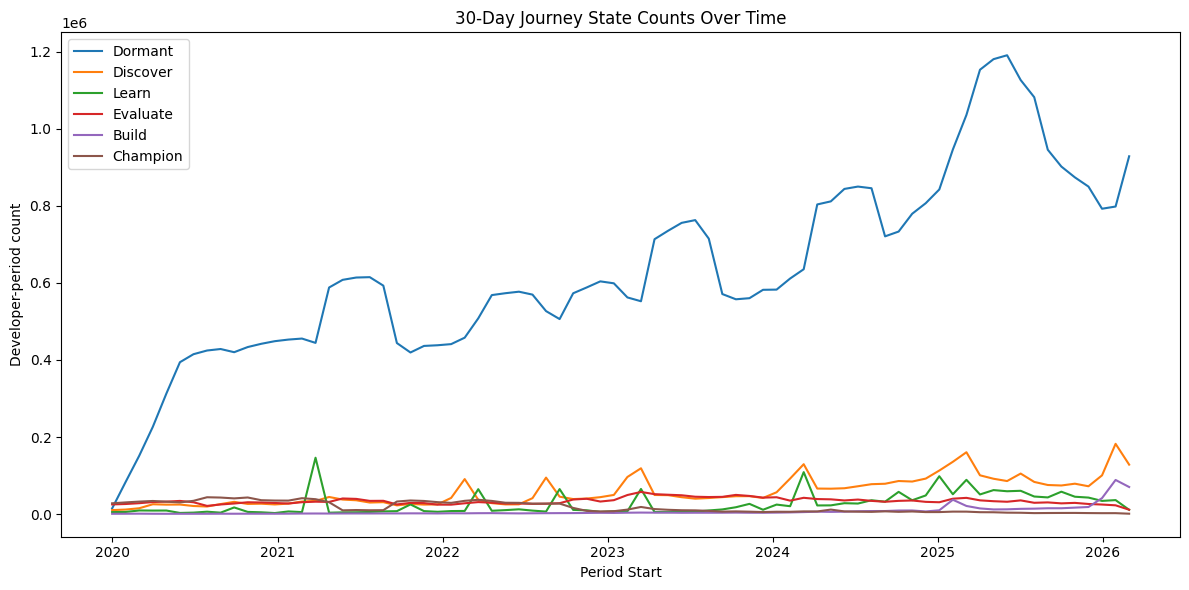

In [70]:
state_over_time = con.execute("""
SELECT anchor_period_index, anchor_period_start, state_30d, COUNT(*) AS developer_periods
FROM dev_period_profile_v1
GROUP BY 1,2,3
ORDER BY 1,3
""").fetchdf()

display(state_over_time.head(30))

pivot = state_over_time.pivot_table(index="anchor_period_start", columns="state_30d", values="developer_periods", fill_value=0)
pivot = pivot.reindex(columns=STATE_ORDER, fill_value=0)

plt.figure(figsize=(12, 6))
for col in pivot.columns:
    plt.plot(pivot.index, pivot[col], label=col)
plt.title("30-Day Journey State Counts Over Time")
plt.xlabel("Period Start")
plt.ylabel("Developer-period count")
plt.legend()
plt.tight_layout()
plt.show()


## 9. Period-to-period transitions

This is the non-cumulative transition table. It compares each developer's current 30-day state to their previous 30-day state across the full dataset.


In [71]:
con.execute("""
CREATE OR REPLACE TABLE dev_period_transitions_v1 AS
WITH ordered AS (
    SELECT
        developer_id,
        anchor_period_index,
        anchor_period_start,
        anchor_period_end,
        state_30d,
        rank_30d,
        activity_count_30d,
        LAG(state_30d) OVER (PARTITION BY developer_id ORDER BY anchor_period_index) AS prev_state_30d,
        LAG(rank_30d) OVER (PARTITION BY developer_id ORDER BY anchor_period_index) AS prev_rank_30d,
        LAG(activity_count_30d) OVER (PARTITION BY developer_id ORDER BY anchor_period_index) AS prev_activity_count_30d
    FROM dev_period_profile_v1
)
SELECT
    *,
    CASE
        WHEN prev_state_30d IS NULL THEN 'First Observed'
        WHEN prev_state_30d = 'Dormant' AND state_30d <> 'Dormant' THEN 'Activated'
        WHEN prev_state_30d <> 'Dormant' AND state_30d = 'Dormant' THEN 'Churned'
        WHEN rank_30d > prev_rank_30d THEN 'Progressed'
        WHEN rank_30d < prev_rank_30d THEN 'Regressed'
        ELSE 'Stable'
    END AS period_transition_type
FROM ordered
""")

display(con.execute("""
SELECT period_transition_type,
       COUNT(*) AS developer_periods,
       COUNT(*) * 1.0 / SUM(COUNT(*)) OVER () AS pct
FROM dev_period_transitions_v1
GROUP BY 1
ORDER BY developer_periods DESC
""").fetchdf())


100% ▕██████████████████████████████████████▏ (00:00:06.22 elapsed)     


,period_transition_type,developer_periods,pct
0,Stable,39253418,0.665193
1,Churned,9433933,0.159868
2,First Observed,7660278,0.129812
3,Activated,2228386,0.037762
4,Progressed,260731,0.004418
5,Regressed,173861,0.002946


### Validation: transition matrix


,prev_state_30d,state_30d,developer_periods
0,Build,Build,237714
1,Build,Champion,5966
2,Build,Discover,3725
3,Build,Dormant,248383
4,Build,Evaluate,6013
5,Build,Learn,5634
6,Champion,Build,6920
7,Champion,Champion,88063
8,Champion,Discover,4516
9,Champion,Dormant,1134321


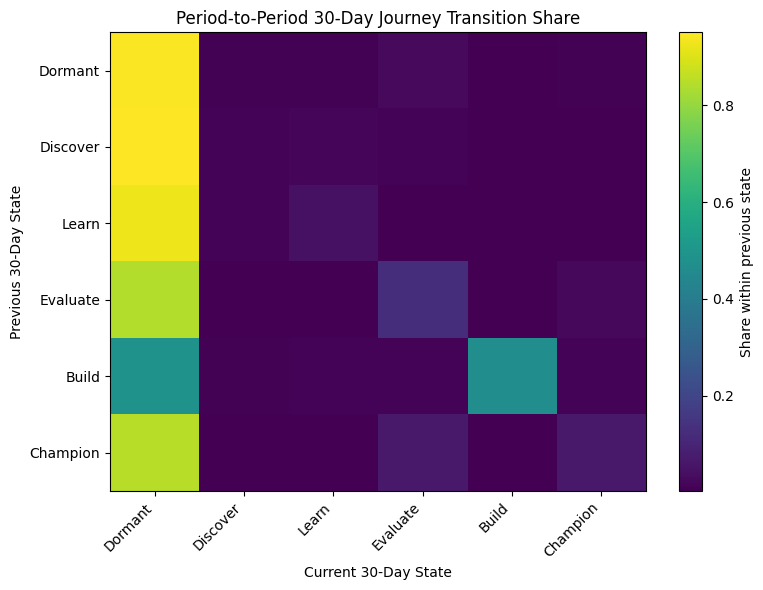

In [72]:
transition_matrix = con.execute("""
SELECT prev_state_30d, state_30d, COUNT(*) AS developer_periods
FROM dev_period_transitions_v1
WHERE prev_state_30d IS NOT NULL
GROUP BY 1,2
ORDER BY 1,2
""").fetchdf()

display(transition_matrix)

heatmap_df = transition_matrix.pivot(index="prev_state_30d", columns="state_30d", values="developer_periods").fillna(0)
heatmap_df = heatmap_df.reindex(index=STATE_ORDER, columns=STATE_ORDER, fill_value=0)
heatmap_pct = heatmap_df.div(heatmap_df.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)

plt.figure(figsize=(8, 6))
plt.imshow(heatmap_pct, aspect="auto")
plt.xticks(range(len(heatmap_pct.columns)), heatmap_pct.columns, rotation=45, ha="right")
plt.yticks(range(len(heatmap_pct.index)), heatmap_pct.index)
plt.title("Period-to-Period 30-Day Journey Transition Share")
plt.xlabel("Current 30-Day State")
plt.ylabel("Previous 30-Day State")
plt.colorbar(label="Share within previous state")
plt.tight_layout()
plt.show()


## 10. Developer longitudinal summary

This table collapses the period panel into one row per developer with longitudinal behavior features.


In [73]:
con.execute("""
CREATE OR REPLACE TABLE dev_longitudinal_summary_v1 AS
SELECT
    developer_id,
    COUNT(*) AS observed_periods_with_recent_activity,
    MIN(anchor_period_start) AS first_observed_period_start,
    MAX(anchor_period_end) AS last_observed_period_end,
    SUM(CASE WHEN state_30d = 'Dormant' THEN 1 ELSE 0 END) AS dormant_periods,
    SUM(CASE WHEN state_30d = 'Discover' THEN 1 ELSE 0 END) AS discover_periods,
    SUM(CASE WHEN state_30d = 'Learn' THEN 1 ELSE 0 END) AS learn_periods,
    SUM(CASE WHEN state_30d = 'Evaluate' THEN 1 ELSE 0 END) AS evaluate_periods,
    SUM(CASE WHEN state_30d = 'Build' THEN 1 ELSE 0 END) AS build_periods,
    SUM(CASE WHEN state_30d = 'Champion' THEN 1 ELSE 0 END) AS champion_periods,
    MAX(rank_30d) AS highest_rank_reached,
    CASE MAX(rank_30d)
        WHEN 0 THEN 'Dormant'
        WHEN 1 THEN 'Discover'
        WHEN 2 THEN 'Learn'
        WHEN 3 THEN 'Evaluate'
        WHEN 4 THEN 'Build'
        WHEN 5 THEN 'Champion'
    END AS highest_state_reached,
    SUM(activity_count_30d) AS panel_activity_count_total,
    AVG(activity_count_30d) AS avg_activity_count_per_observed_period,
    MAX(activity_count_30d) AS max_activity_count_in_period,
    SUM(CASE WHEN state_30d <> 'Dormant' THEN 1 ELSE 0 END) AS active_period_count,
    SUM(CASE WHEN state_30d = 'Build' OR state_30d = 'Champion' THEN 1 ELSE 0 END) AS deep_engagement_period_count
FROM dev_period_profile_v1
GROUP BY developer_id
""")

display(con.execute("""
SELECT
    COUNT(*) AS rows,
    COUNT(DISTINCT developer_id) AS developers,
    AVG(observed_periods_with_recent_activity) AS avg_observed_periods,
    MAX(observed_periods_with_recent_activity) AS max_observed_periods
FROM dev_longitudinal_summary_v1
""").fetchdf())

display(con.execute("""
SELECT highest_state_reached, COUNT(*) AS developers
FROM dev_longitudinal_summary_v1
GROUP BY 1
ORDER BY developers DESC
""").fetchdf())


100% ▕██████████████████████████████████████▏ (00:00:10.47 elapsed)     


,rows,developers,avg_observed_periods,max_observed_periods
0,7660278,7660278,7.703455,76


,highest_state_reached,developers
0,Discover,3575020
1,Learn,1455968
2,Evaluate,1175914
3,Champion,1057758
4,Build,243028
5,Dormant,152590


## 11. Update final profile with lifetime persona and longitudinal context

This keeps your one-row-per-developer output but improves it with stable persona and historical behavior.


In [74]:
con.execute("""
CREATE OR REPLACE TABLE dev_profile_final_v2 AS
SELECT
    f.developer_id,
    COALESCE(lp.persona, f.persona, 'Unknown') AS persona,
    COALESCE(lp.persona_confidence, f.persona_confidence, 0.0) AS persona_confidence,
    COALESCE(lp.persona_confidence_tier, f.persona_confidence_tier, 'Unknown') AS persona_confidence_tier,
    COALESCE(lp.mixed_persona_flag, f.mixed_persona_flag, 0) AS mixed_persona_flag,
    f.current_journey_state_30d,
    f.current_journey_state_confidence,
    f.recent_journey_state_90d,
    f.historical_journey_state_180d,
    f.transition_90d_to_30d,
    f.trajectory_label,
    f.activity_count_30d,
    f.activity_count_90d,
    f.activity_count_180d,
    lf.lifetime_activity_count_total,
    lf.lifetime_activity_score_sum,
    lf.first_activity_date,
    lf.last_activity_date,
    lf.days_since_last_activity_lifetime,
    ls.highest_state_reached,
    ls.observed_periods_with_recent_activity,
    ls.active_period_count,
    ls.deep_engagement_period_count,
    ls.max_activity_count_in_period
FROM dev_profile_final_v1 f
LEFT JOIN dev_persona_lifetime_v1 lp USING (developer_id)
LEFT JOIN dev_features_lifetime_v1 lf USING (developer_id)
LEFT JOIN dev_longitudinal_summary_v1 ls USING (developer_id)
""")

display(con.execute("""
SELECT
    COUNT(*) AS rows,
    COUNT(DISTINCT developer_id) AS developers,
    SUM(CASE WHEN persona IS NULL THEN 1 ELSE 0 END) AS missing_persona,
    SUM(CASE WHEN current_journey_state_30d IS NULL THEN 1 ELSE 0 END) AS missing_current_state
FROM dev_profile_final_v2
""").fetchdf())

display(con.execute("""
SELECT persona, current_journey_state_30d, COUNT(*) AS developers
FROM dev_profile_final_v2
GROUP BY 1,2
ORDER BY developers DESC
LIMIT 30
""").fetchdf())


100% ▕██████████████████████████████████████▏ (00:00:04.17 elapsed)     


,rows,developers,missing_persona,missing_current_state
0,9381508,9381508,0.0,0.0


,persona,current_journey_state_30d,developers
0,CUDA,Dormant,3135069
1,Unknown,Dormant,1779313
2,GenAI,Dormant,1472000
3,Other,Dormant,1131953
4,Robotics,Dormant,592029
5,Simulation,Dormant,432442
6,Learning_Community,Dormant,420508
7,GenAI,Discover,176286
8,GenAI,Build,91757
9,CUDA,Evaluate,24880


## 12. Optional: HMM-ready weekly sequence preparation

Use weekly or 30-day period sequences for HMM. Weekly is usually better for sequence modeling, but 30-day periods are easier to explain. This section validates the existing weekly table if it exists.


In [75]:
if "dev_weekly_features_v1" in set(con.execute("SHOW TABLES").fetchdf().iloc[:, 0].astype(str)):
    display(con.execute("""
    SELECT
        COUNT(*) AS weekly_rows,
        COUNT(DISTINCT developer_id) AS developers,
        COUNT(DISTINCT week_start) AS weeks,
        MIN(week_start) AS first_week,
        MAX(week_start) AS last_week
    FROM dev_weekly_features_v1
    """).fetchdf())

    display(con.execute("""
    SELECT
        approx_quantile(activity_count_total, 0.50) AS p50_activity,
        approx_quantile(activity_count_total, 0.90) AS p90_activity,
        approx_quantile(activity_count_total, 0.99) AS p99_activity,
        MAX(activity_count_total) AS max_activity
    FROM dev_weekly_features_v1
    """).fetchdf())
else:
    print("dev_weekly_features_v1 does not exist yet. Use the previous notebook's optional weekly feature cell first.")


,weekly_rows,developers,weeks,first_week,last_week
0,14908480,7660278,324,2019-12-30,2026-03-09


,p50_activity,p90_activity,p99_activity,max_activity
0,2,6,65,36246


## 13. Export model-ready samples

For large data, avoid loading the full panel into Python. Start with a sample or export to Parquet for downstream modeling.


In [76]:
# Example: create a sampled period panel for local modeling/debugging.
# Adjust sample size as needed.

SAMPLE_DEVELOPERS = 100_000

con.execute(f"""
CREATE OR REPLACE TABLE dev_period_profile_sample_v1 AS
WITH sampled_devs AS (
    SELECT developer_id
    FROM dev_longitudinal_summary_v1
    WHERE active_period_count >= 2
    USING SAMPLE {SAMPLE_DEVELOPERS} ROWS
)
SELECT p.*
FROM dev_period_profile_v1 p
JOIN sampled_devs s USING (developer_id)
""")

display(con.execute("""
SELECT COUNT(*) AS rows,
       COUNT(DISTINCT developer_id) AS developers,
       COUNT(DISTINCT anchor_period_index) AS periods
FROM dev_period_profile_sample_v1
""").fetchdf())

# Optional export. Uncomment if desired.
# con.execute("COPY dev_profile_final_v2 TO 'dev_profile_final_v2.parquet' (FORMAT PARQUET)")
# con.execute("COPY dev_period_profile_sample_v1 TO 'dev_period_profile_sample_v1.parquet' (FORMAT PARQUET)")


100% ▕██████████████████████████████████████▏ (00:00:02.71 elapsed)     


,rows,developers,periods
0,288652,19432,76


## 14. Close connection


In [77]:
con.close()
